In [1]:
import netCDF4 as nc
import os

#base = "/Users/bernardnkrumahattobrah/Documents/HydroBlocks/data/snow_experiment/experiments/simulations/MSWX_3h_Snow_Project_Bernard"
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"
cid = 1

input_file = os.path.join(path_pp, f"{cid}/input_file.nc")
output_file = os.path.join(path_pp, f"output_data/{cid}/2016-01-01.nc")

def list_nc_vars(path):
    print(f"\n--- File: {path} ---")
    with nc.Dataset(path) as ds:
        for gname, grp in ds.groups.items():
            print(f"\n[Group: {gname}]")
            for vname, var in grp.variables.items():
                print(f"  {vname:20s} shape={var.shape} dims={var.dimensions}")

# Inspect static (parameters/meteorology)
list_nc_vars(input_file)

# Inspect dynamic outputs
list_nc_vars(output_file)



--- File: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/1/input_file.nc ---

[Group: meteorology]
  lwdown               shape=(8744, 1000) dims=('time', 'hru')
  swdown               shape=(8744, 1000) dims=('time', 'hru')
  tair                 shape=(8744, 1000) dims=('time', 'hru')
  precip               shape=(8744, 1000) dims=('time', 'hru')
  psurf                shape=(8744, 1000) dims=('time', 'hru')
  wind                 shape=(8744, 1000) dims=('time', 'hru')
  spfh                 shape=(8744, 1000) dims=('time', 'hru')
  time                 shape=(8744,) dims=('time',)

[Group: water_use]

[Group: metadata]

[Group: wmatrix_Basin1]
  data                 shape=(4,) dims=('connections_columns',)
  indices              shape=(4,) dims=('connections_columns',)
  indptr               shape=(3,) dims=('connections_rows',)

[Group: wmatrix_Basin2]
  data                 shape=(4,) dims=('connections_c

In [3]:
import numpy as np
import netCDF4 as nc
import numba
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import gdal_tools
import sys
import matplotlib.pyplot as plt
import rasterio
import os, re, glob
import matplotlib.colors as colors
from pathlib import Path

# model outputs
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"
path_3d = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/"

# choose which run to use here
path = path_3d

# output directory
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Surface_Temp_Plots"
os.makedirs(outputdir, exist_ok=True)

# READ TIME (FROM INPUT FILE)
fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]
fp.close()

# BUILD DATETIME VECTOR
start = pd.Timestamp("2016-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# Read HRU grid + metadata
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

buffer = 250
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

with rasterio.open(path + "postprocess/cids.vrt") as ds:
    cids = ds.read(1)

with nc.Dataset(path + "output_data/1/2016-01-01.nc") as ds:
    nhrus = ds.groups["data"].variables["totsmc"].shape[1]

def read_grid(fp):
    with rasterio.open(fp) as ds:
        arr = ds.read(1)
        nod = ds.nodata
        if nod is not None:
            arr[arr == nod] = np.nan
        arr[arr == -9999.0] = np.nan
        return arr

def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out

/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


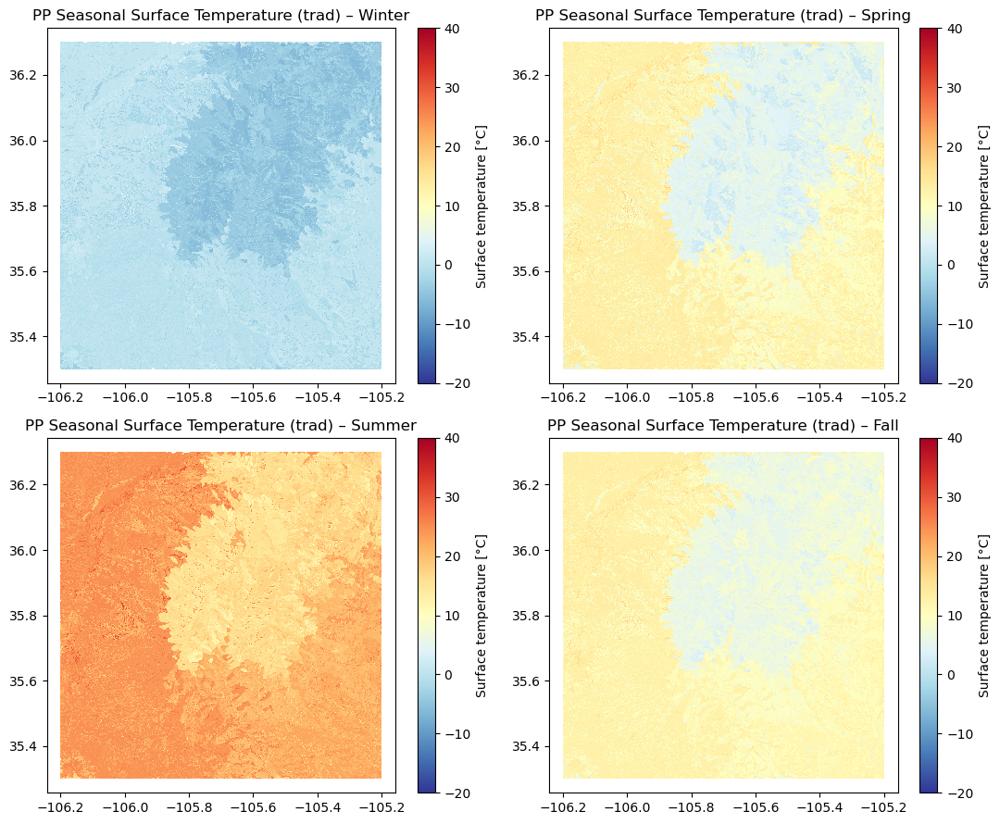

In [3]:
# PP surface temperature (trad) seasonal plots
# all times included (not split into daytime or nighttime)

path = path_pp
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

# Fixed color scale in Celsius
lst_norm = colors.Normalize(vmin=-20, vmax=40)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        # Read surface radiative temperature
        trad = np.array(grp.variables["trad"][:])   # (time, hru), K

        fp.close()

        # Seasonal mask (1D over time)
        season_mask = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        ).values

        # Keep only this season
        data_sel = trad[season_mask, :]

        # Convert K to C
        data_sel = data_sel - 273.15

        # Mean over time -> one value per HRU
        data_ave = np.nanmean(data_sel, axis=0)   # (hru,)

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    # Mask invalid
    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan

    # Crop edges
    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="RdYlBu_r",
        norm=lst_norm,
        shading="auto"
    )

    ax.set_title(f"PP Seasonal Surface Temperature (trad) – {my_season}")
    fig.colorbar(im, ax=ax, label="Surface temperature [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_trad_seasonal_pp.png"),
    dpi=300
)
plt.show()

/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


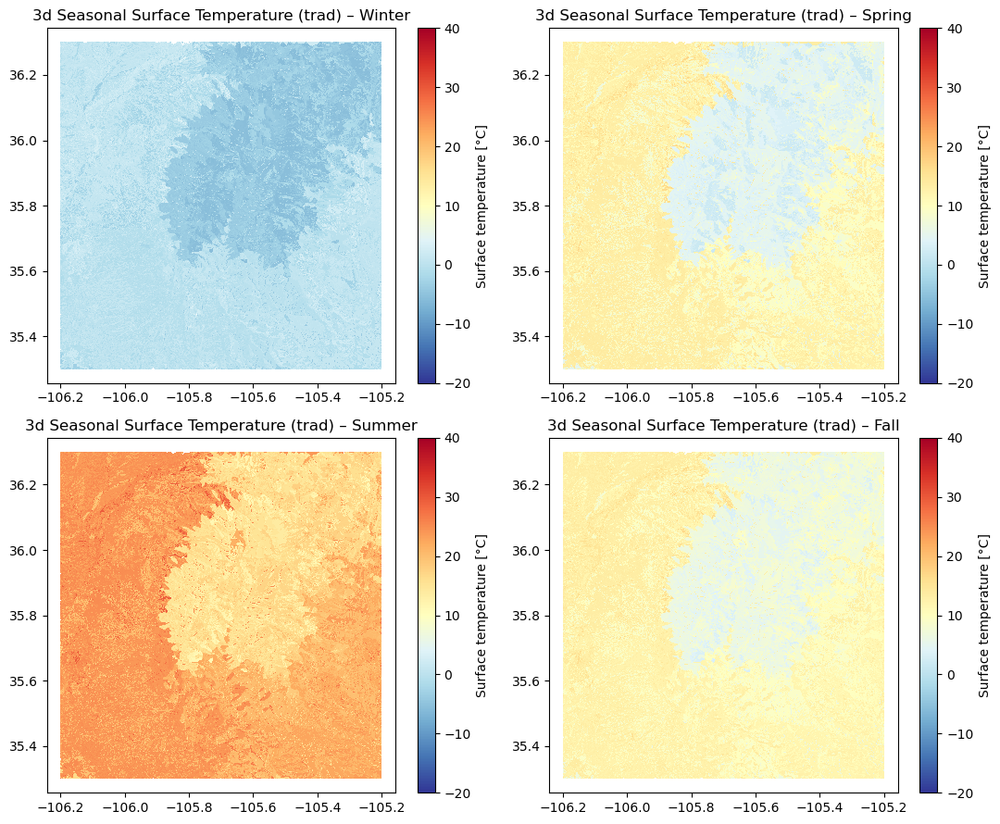

In [4]:
# PP surface temperature (trad) seasonal plots
# all times included (not split into daytime or nighttime)

path = path_3d
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

# Fixed color scale in Celsius
lst_norm = colors.Normalize(vmin=-20, vmax=40)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        # Read surface radiative temperature
        trad = np.array(grp.variables["trad"][:])   # (time, hru), K

        fp.close()

        # Seasonal mask (1D over time)
        season_mask = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        ).values

        # Keep only this season
        data_sel = trad[season_mask, :]

        # Convert K to C
        data_sel = data_sel - 273.15

        # Mean over time -> one value per HRU
        data_ave = np.nanmean(data_sel, axis=0)   # (hru,)

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    # Mask invalid
    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan

    # Crop edges
    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="RdYlBu_r",
        norm=lst_norm,
        shading="auto"
    )

    ax.set_title(f"3d Seasonal Surface Temperature (trad) – {my_season}")
    fig.colorbar(im, ax=ax, label="Surface temperature [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_trad_seasonal_3d.png"),
    dpi=300
)
plt.show()

PP vs 3D trad: Winter
PP vs 3D trad: Spring
PP vs 3D trad: Summer
PP vs 3D trad: Fall


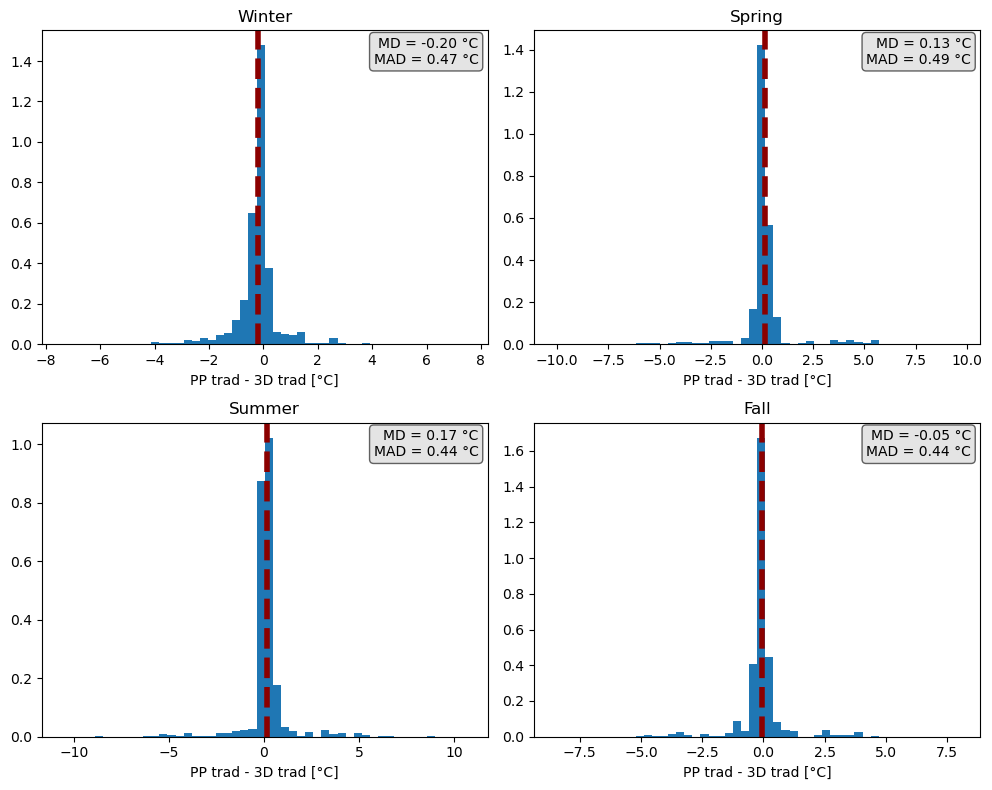

In [5]:
# PP vs 3D difference Histogram Plot (Surface temperature from trad)
# Difference = PP trad - 3D trad

path_domain = path_pp  # use PP domain for mapping

hrus_pp = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
cids_pp = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")

hrus_3d = gdal_tools.read_raster(path_3d + "postprocess/hrus.vrt")
cids_3d = gdal_tools.read_raster(path_3d + "postprocess/cids.vrt")

tmp_pp = np.copy(hrus_pp)
tmp_pp[:] = -9999.0

tmp_3d = np.copy(hrus_3d)
tmp_3d[:] = -9999.0

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# read PP outputs once
fp_pp = nc.Dataset(path_pp + "output_data/1/2016-01-01.nc")
trad_pp = np.array(fp_pp.groups["data"].variables["trad"][:])  # (time, hru), K
fp_pp.close()

# read 3D outputs once
fp_3d = nc.Dataset(path_3d + "output_data/1/2016-01-01.nc")
trad_3d = np.array(fp_3d.groups["data"].variables["trad"][:])  # (time, hru), K
fp_3d.close()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[my_season]

    print(f"PP vs 3D trad: {my_season}")

    # seasonal mean trad (HRU)
    idx = times.dt.month.isin(my_months).to_numpy()

    trad_pp_mean = np.nanmean(trad_pp[idx, :], axis=0) - 273.15
    trad_3d_mean = np.nanmean(trad_3d[idx, :], axis=0) - 273.15

    # map HRU to grid
    trad_pp_grid = place_data(tmp_pp, trad_pp_mean, hrus_pp, cids_pp, 1)
    trad_pp_grid = np.where(trad_pp_grid == -9999, np.nan, trad_pp_grid)
    trad_pp_grid = trad_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    trad_3d_grid = place_data(tmp_3d, trad_3d_mean, hrus_3d, cids_3d, 1)
    trad_3d_grid = np.where(trad_3d_grid == -9999, np.nan, trad_3d_grid)
    trad_3d_grid = trad_3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    if trad_pp_grid.shape != trad_3d_grid.shape:
        raise ValueError(f"Shape mismatch: PP {trad_pp_grid.shape}, 3D {trad_3d_grid.shape}")

    # difference + histogram
    valid = np.isfinite(trad_pp_grid) & np.isfinite(trad_3d_grid)
    arr = (trad_pp_grid - trad_3d_grid)[valid]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    md = np.mean(arr)
    mad = np.mean(np.abs(arr))

    ax.text(
        0.98, 0.98,
        f"MD = {md:.2f} °C\nMAD = {mad:.2f} °C",
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            boxstyle="round",
            facecolor="lightgray",
            edgecolor="black",
            alpha=0.6
        )
    )

    ax.set_title(my_season)
    ax.set_xlabel("PP trad - 3D trad [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_trad_PP_minus_3D.png"),
    dpi=300
)
plt.show()

/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


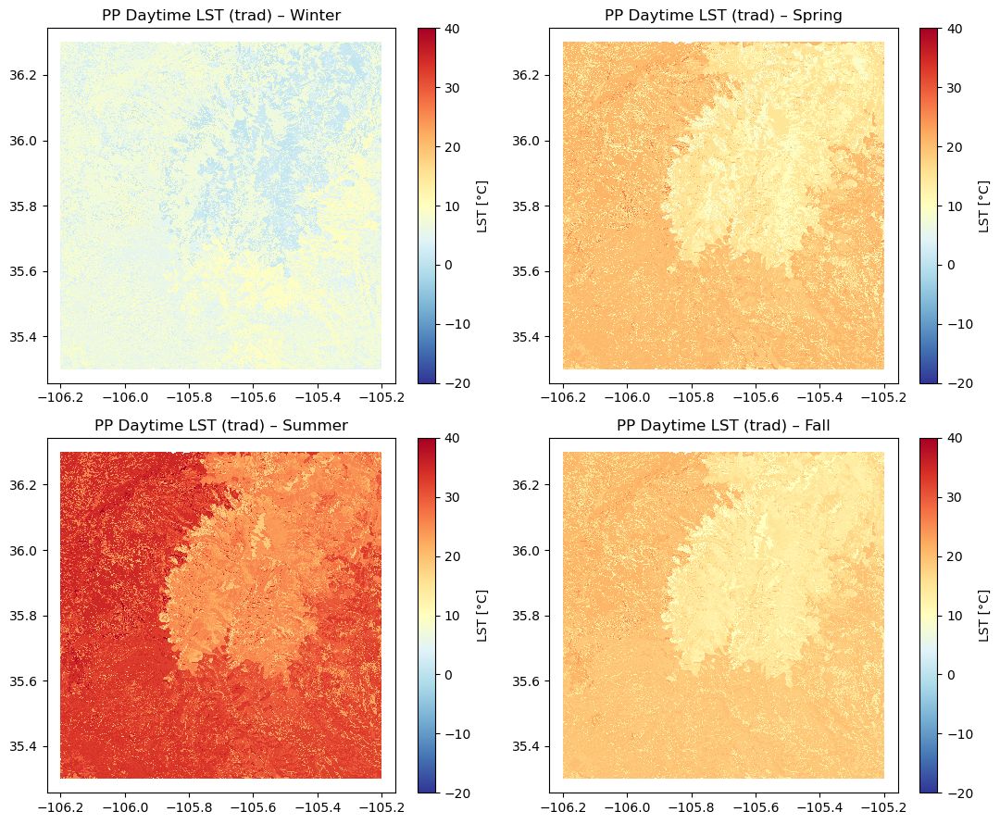

In [6]:
# PP daytime land surface temperature (trad) seasonal plots
# daytime defined using solar geometry: cosz > 0.0 or 0.3

path = path_pp
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

# Fixed color scale in Celsius
lst_norm = colors.Normalize(vmin=-20, vmax=40)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        # Read land surface temperature and solar geometry
        trad = np.array(grp.variables["trad"][:])   # (time, hru), K
        cosz = np.array(grp.variables["cosz"][:])   # (time, hru)

        fp.close()

        # Seasonal mask (1D over time)
        season_mask = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        ).values

        # Daytime mask from solar zenith angle (2D: time, hru)
        solar_mask = cosz > 0.3

        # Combine seasonal and daytime masks
        mask_2d = season_mask[:, None] & solar_mask

        # Keep only daytime trad values for this season
        data_sel = np.where(mask_2d, trad, np.nan)

        # Convert K to C
        data_sel = data_sel - 273.15

        # Mean over time -> one value per HRU
        data_ave = np.nanmean(data_sel, axis=0)   # (hru,)

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    # Mask invalid
    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan

    # Crop edges
    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="RdYlBu_r",
        norm=lst_norm,
        shading="auto"
    )

    ax.set_title(f"PP Daytime LST (trad) – {my_season}")
    fig.colorbar(im, ax=ax, label="LST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_trad_daytime_seasonal_pp.png"),
    dpi=300
)
plt.show()

/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


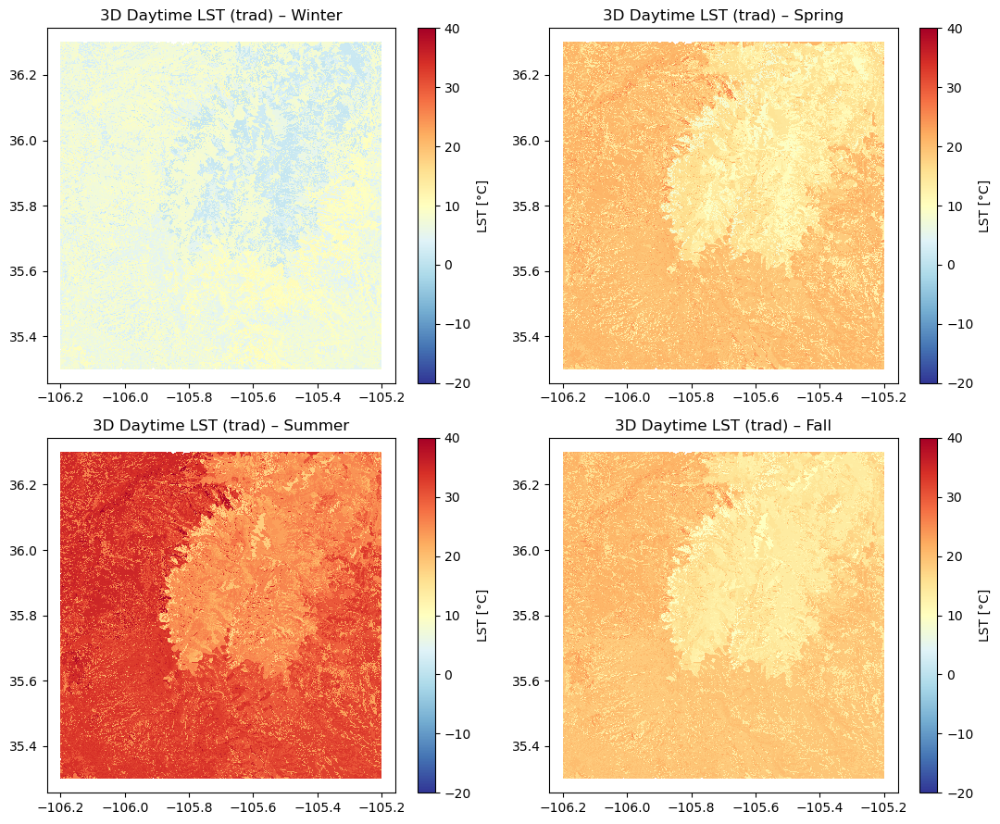

In [7]:
# daytime land surface temperature (trad) seasonal plots
# daytime defined using solar geometry: cosz > 0.0

path = path_3d
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path_3d + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_3d + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

# Fixed color scale in Celsius
lst_norm = colors.Normalize(vmin=-20, vmax=40)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path_3d + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        # Read land surface temperature and solar geometry
        trad = np.array(grp.variables["trad"][:])   # (time, hru), K
        cosz = np.array(grp.variables["cosz"][:])   # (time, hru)

        fp.close()

        # Seasonal mask (1D over time)
        season_mask = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        ).values

        # Daytime mask from solar zenith angle (2D: time, hru)
        solar_mask = cosz > 0.3

        # Combine seasonal and daytime masks
        mask_2d = season_mask[:, None] & solar_mask

        # Keep only daytime trad values for this season
        data_sel = np.where(mask_2d, trad, np.nan)

        # Convert K to C
        data_sel = data_sel - 273.15

        # Mean over time -> one value per HRU
        data_ave = np.nanmean(data_sel, axis=0)   # (hru,)

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    # Mask invalid
    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan

    # Crop edges
    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="RdYlBu_r",
        norm=lst_norm,
        shading="auto"
    )

    ax.set_title(f"3D Daytime LST (trad) – {my_season}")
    fig.colorbar(im, ax=ax, label="LST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_trad_daytime_seasonal_3d.png"),
    dpi=300
)
plt.show()

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/
Creating daytime LST difference plot for Winter
Creating daytime LST difference plot for Spring
Creating daytime LST difference plot for Summer
Creating daytime LST difference plot for Fall


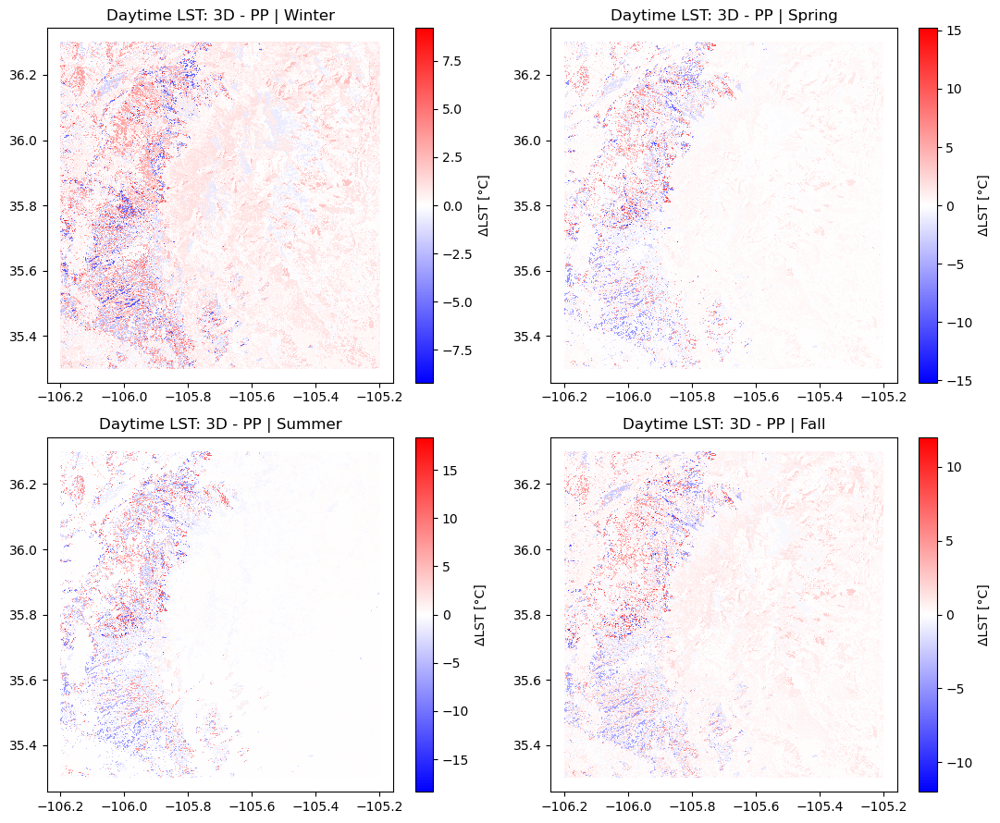

In [8]:
# 3D - PP seasonal difference maps (Daytime LST from trad)
# Difference = 3D daytime LST - PP daytime LST
# assumes times, seasons, season_months, buffer, coords_x, coords_y already exist

print("3D:", path_3d)
print("PP:", path_pp)

# Read mapping rasters for BOTH runs
hrus_pp = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
cids_pp = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")
tmp_pp = np.copy(hrus_pp)
tmp_pp[:] = -9999.0

hrus_3d = gdal_tools.read_raster(path_3d + "postprocess/hrus.vrt")
cids_3d = gdal_tools.read_raster(path_3d + "postprocess/cids.vrt")
tmp_3d = np.copy(hrus_3d)
tmp_3d[:] = -9999.0

# Read trad and cosz once for BOTH runs
with nc.Dataset(path_pp + "output_data/1/2016-01-01.nc") as fp:
    grp = fp.groups["data"]
    trad_pp = np.array(grp.variables["trad"][:])   # (time, hru), K
    cosz_pp = np.array(grp.variables["cosz"][:])   # (time, hru)

with nc.Dataset(path_3d + "output_data/1/2016-01-01.nc") as fp:
    grp = fp.groups["data"]
    trad_3d = np.array(grp.variables["trad"][:])   # (time, hru), K
    cosz_3d = np.array(grp.variables["cosz"][:])   # (time, hru)

# Plot seasonal differences
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating daytime LST difference plot for {my_season}")

    # Seasonal mask
    season_mask = (
        (times.dt.month == my_months[0]) |
        (times.dt.month == my_months[1]) |
        (times.dt.month == my_months[2])
    ).values

    # Daytime masks
    mask_pp = season_mask[:, None] & (cosz_pp > 0.3)
    mask_3d = season_mask[:, None] & (cosz_3d > 0.3)

    # Keep only daytime trad values, convert to C, then seasonal mean
    trad_pp_day = np.where(mask_pp, trad_pp, np.nan) - 273.15
    trad_3d_day = np.where(mask_3d, trad_3d, np.nan) - 273.15

    trad_pp_ave = np.nanmean(trad_pp_day, axis=0)   # (hru,)
    trad_3d_ave = np.nanmean(trad_3d_day, axis=0)   # (hru,)

    # Map each run using its own HRU/CID rasters
    map_pp = place_data(tmp_pp, trad_pp_ave, hrus_pp, cids_pp, 1)
    map_3d = place_data(tmp_3d, trad_3d_ave, hrus_3d, cids_3d, 1)

    map_pp = np.where(map_pp == -9999, np.nan, map_pp)
    map_3d = np.where(map_3d == -9999, np.nan, map_3d)

    # Crop edges
    shape_pp = map_pp.shape
    shape_3d = map_3d.shape

    map_pp = map_pp[
        buffer:shape_pp[0] - buffer + 1,
        buffer:shape_pp[1] - buffer + 1
    ]

    map_3d = map_3d[
        buffer:shape_3d[0] - buffer + 1,
        buffer:shape_3d[1] - buffer + 1
    ]

    # dimension check
    if map_pp.shape != map_3d.shape:
        raise ValueError(f"Shape mismatch: PP {map_pp.shape}, 3D {map_3d.shape}")

    # Difference
    final_map = map_3d - map_pp

    # Diverging scale centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue

    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="bwr",
        norm=diff_norm,
        shading="auto"
    )

    ax.set_title(f"Daytime LST: 3D - PP | {my_season}")
    fig.colorbar(im, ax=ax, label="ΔLST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_trad_daytime_3D_minus_PP.png"),
    dpi=300
)
plt.show()

3D vs PP daytime LST: Winter
3D vs PP daytime LST: Spring
3D vs PP daytime LST: Summer
3D vs PP daytime LST: Fall


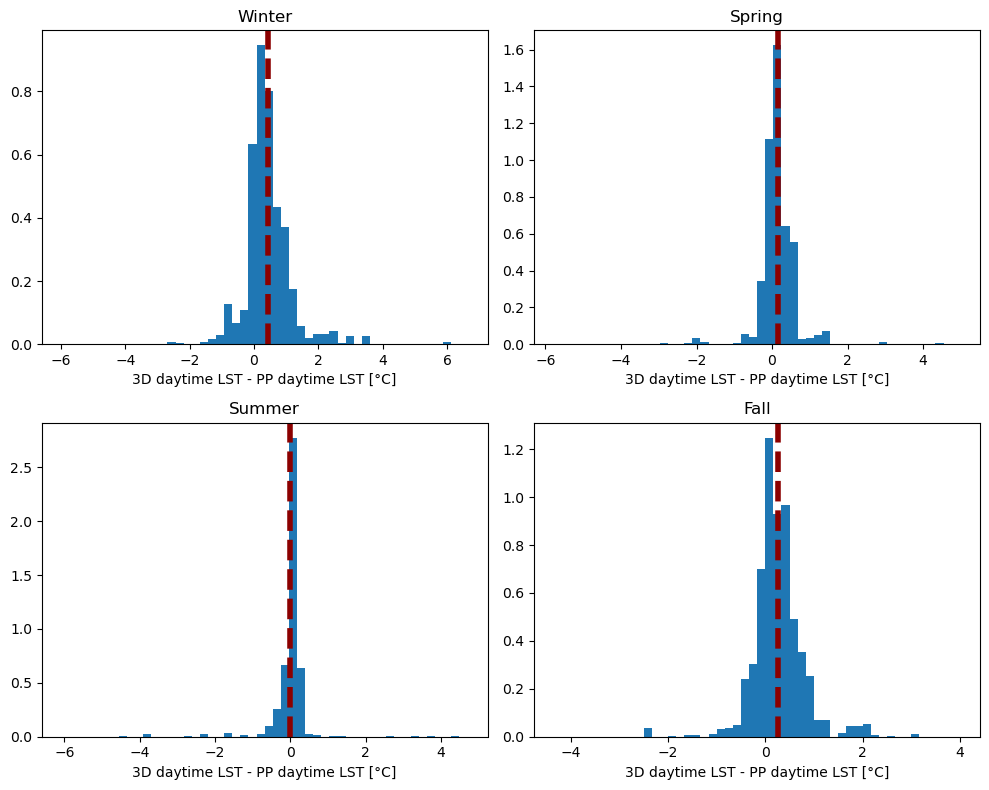

In [9]:
# 3D vs PP difference Histogram Plot (Daytime land surface temperature)
# Difference = 3D daytime LST - PP daytime LST

path_domain = path_3d  # use 3D domain for mapping

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# read outputs once
fp_3d = nc.Dataset(path_3d + "output_data/1/2016-01-01.nc")
trad_3d = np.array(fp_3d.groups["data"].variables["trad"][:])  # (time, hru), K
cosz_3d = np.array(fp_3d.groups["data"].variables["cosz"][:])  # (time, hru)
fp_3d.close()

fp_pp = nc.Dataset(path_pp + "output_data/1/2016-01-01.nc")
trad_pp = np.array(fp_pp.groups["data"].variables["trad"][:])  # (time, hru), K
cosz_pp = np.array(fp_pp.groups["data"].variables["cosz"][:])  # (time, hru)
fp_pp.close()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"3D vs PP daytime LST: {my_season}")

    # seasonal mask
    idx = times.dt.month.isin(my_months).to_numpy()

    # 3D seasonal daytime mean LST (HRU)
    mask_3d = idx[:, None] & (cosz_3d > 0.3)
    trad_3d_day = np.where(mask_3d, trad_3d, np.nan) - 273.15
    trad_3d_mean = np.nanmean(trad_3d_day, axis=0)

    # map 3D HRU → grid
    trad_3d_grid = place_data(tmp, trad_3d_mean, hrus, cids, 1)
    trad_3d_grid = np.where(trad_3d_grid == -9999, np.nan, trad_3d_grid)
    trad_3d_grid = trad_3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    # PP seasonal daytime mean LST (HRU)
    mask_pp = idx[:, None] & (cosz_pp > 0.3)
    trad_pp_day = np.where(mask_pp, trad_pp, np.nan) - 273.15
    trad_pp_mean = np.nanmean(trad_pp_day, axis=0)

    # map PP HRU to grid
    trad_pp_grid = place_data(tmp, trad_pp_mean, hrus, cids, 1)
    trad_pp_grid = np.where(trad_pp_grid == -9999, np.nan, trad_pp_grid)
    trad_pp_grid = trad_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    # difference + histogram
    diff = trad_3d_grid - trad_pp_grid
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("3D daytime LST - PP daytime LST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_trad_daytime_3D_minus_PP.png"),
    dpi=300
)
plt.show()

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/
Creating nighttime LST difference plot for Winter
Creating nighttime LST difference plot for Spring
Creating nighttime LST difference plot for Summer
Creating nighttime LST difference plot for Fall


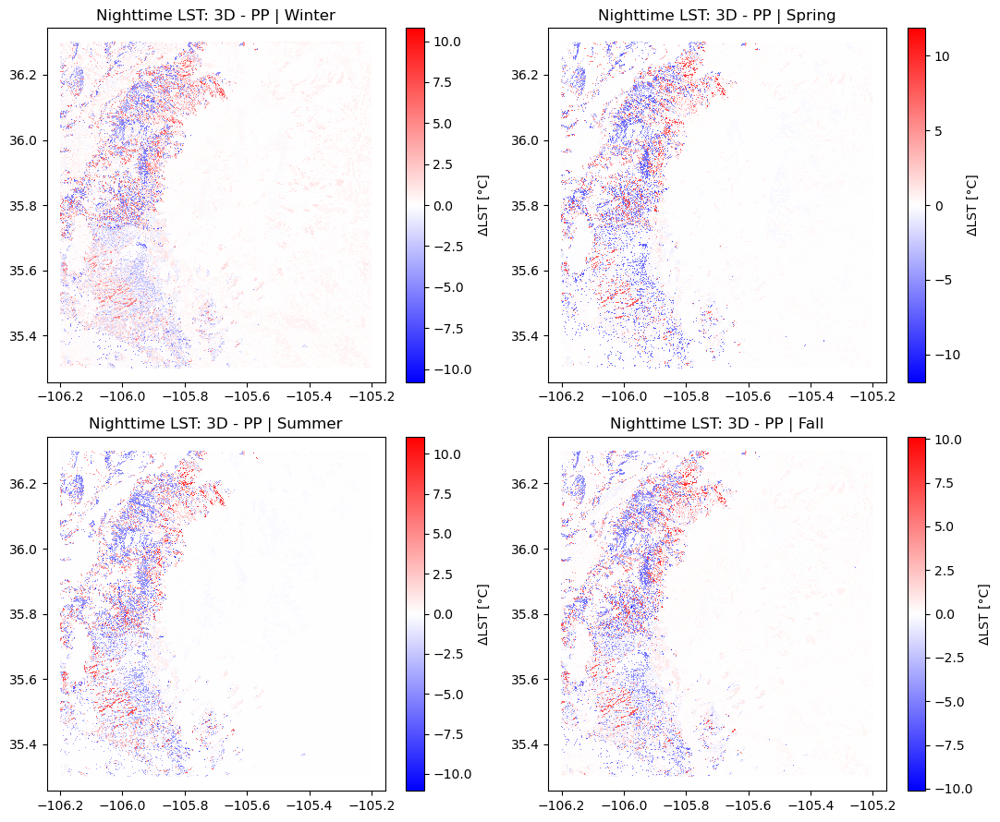

In [10]:
# Nighttime temperature
# 3D - PP seasonal difference maps (Nighttime LST from trad)
# Difference = 3D nighttime LST - PP nighttime LST
print("3D:", path_3d)
print("PP:", path_pp)

# Read mapping rasters for BOTH runs
hrus_pp = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
cids_pp = gdal_tools.read_raster(path_pp + "postprocess/cids.vrt")
tmp_pp = np.copy(hrus_pp)
tmp_pp[:] = -9999.0

hrus_3d = gdal_tools.read_raster(path_3d + "postprocess/hrus.vrt")
cids_3d = gdal_tools.read_raster(path_3d + "postprocess/cids.vrt")
tmp_3d = np.copy(hrus_3d)
tmp_3d[:] = -9999.0

# Read trad and cosz once for BOTH runs
with nc.Dataset(path_pp + "output_data/1/2016-01-01.nc") as fp:
    grp = fp.groups["data"]
    trad_pp = np.array(grp.variables["trad"][:])   # (time, hru), K
    cosz_pp = np.array(grp.variables["cosz"][:])   # (time, hru)

with nc.Dataset(path_3d + "output_data/1/2016-01-01.nc") as fp:
    grp = fp.groups["data"]
    trad_3d = np.array(grp.variables["trad"][:])   # (time, hru), K
    cosz_3d = np.array(grp.variables["cosz"][:])   # (time, hru)

# Plot seasonal differences
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating nighttime LST difference plot for {my_season}")

    # Seasonal mask
    season_mask = (
        (times.dt.month == my_months[0]) |
        (times.dt.month == my_months[1]) |
        (times.dt.month == my_months[2])
    ).values

    # Nighttime masks
    mask_pp = season_mask[:, None] & (cosz_pp < 0.0)
    mask_3d = season_mask[:, None] & (cosz_3d < 0.0)

    # Keep only nighttime trad values, convert to C, then seasonal mean
    trad_pp_night = np.where(mask_pp, trad_pp, np.nan) - 273.15
    trad_3d_night = np.where(mask_3d, trad_3d, np.nan) - 273.15

    trad_pp_ave = np.nanmean(trad_pp_night, axis=0)   # (hru,)
    trad_3d_ave = np.nanmean(trad_3d_night, axis=0)   # (hru,)

    # Map each run using its own HRU/CID rasters
    map_pp = place_data(tmp_pp, trad_pp_ave, hrus_pp, cids_pp, 1)
    map_3d = place_data(tmp_3d, trad_3d_ave, hrus_3d, cids_3d, 1)

    map_pp = np.where(map_pp == -9999, np.nan, map_pp)
    map_3d = np.where(map_3d == -9999, np.nan, map_3d)

    # Crop edges
    shape_pp = map_pp.shape
    shape_3d = map_3d.shape

    map_pp = map_pp[
        buffer:shape_pp[0] - buffer + 1,
        buffer:shape_pp[1] - buffer + 1
    ]

    map_3d = map_3d[
        buffer:shape_3d[0] - buffer + 1,
        buffer:shape_3d[1] - buffer + 1
    ]

    # Safety check
    if map_pp.shape != map_3d.shape:
        raise ValueError(f"Shape mismatch: PP {map_pp.shape}, 3D {map_3d.shape}")

    # Difference
    final_map = map_3d - map_pp

    # Diverging scale centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue

    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="bwr",
        norm=diff_norm,
        shading="auto"
    )

    ax.set_title(f"Nighttime LST: 3D - PP | {my_season}")
    fig.colorbar(im, ax=ax, label="ΔLST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_trad_nighttime_3D_minus_PP.png"),
    dpi=300
)
plt.show()

3D vs PP daytime LST: Winter
3D vs PP daytime LST: Spring
3D vs PP daytime LST: Summer
3D vs PP daytime LST: Fall


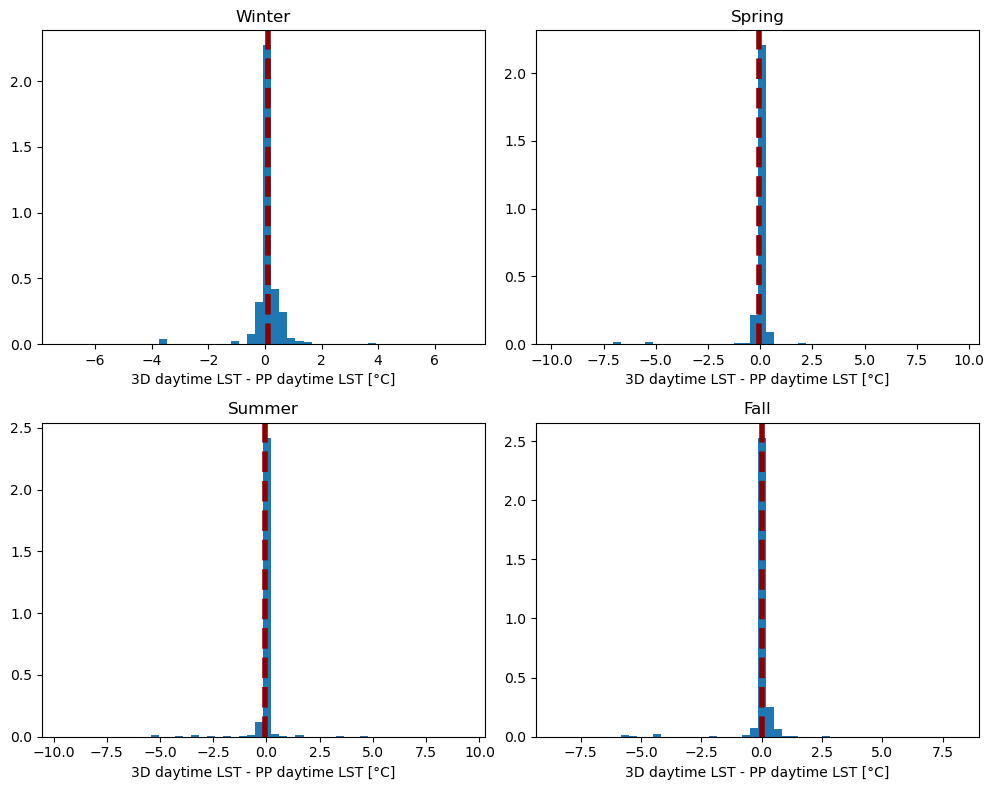

In [11]:
# 3D vs PP difference Histogram Plot (Daytime land surface temperature)
# Difference = 3D daytime LST - PP daytime LST

path_domain = path_3d  # use 3D domain for mapping

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# read outputs once
fp_3d = nc.Dataset(path_3d + "output_data/1/2016-01-01.nc")
trad_3d = np.array(fp_3d.groups["data"].variables["trad"][:])  # (time, hru), K
cosz_3d = np.array(fp_3d.groups["data"].variables["cosz"][:])  # (time, hru)
fp_3d.close()

fp_pp = nc.Dataset(path_pp + "output_data/1/2016-01-01.nc")
trad_pp = np.array(fp_pp.groups["data"].variables["trad"][:])  # (time, hru), K
cosz_pp = np.array(fp_pp.groups["data"].variables["cosz"][:])  # (time, hru)
fp_pp.close()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"3D vs PP daytime LST: {my_season}")

    # seasonal mask
    idx = times.dt.month.isin(my_months).to_numpy()

    # 3D seasonal daytime mean LST (HRU)
    mask_3d = idx[:, None] & (cosz_3d < 0.0)
    trad_3d_day = np.where(mask_3d, trad_3d, np.nan) - 273.15
    trad_3d_mean = np.nanmean(trad_3d_day, axis=0)

    # map 3D HRU → grid
    trad_3d_grid = place_data(tmp, trad_3d_mean, hrus, cids, 1)
    trad_3d_grid = np.where(trad_3d_grid == -9999, np.nan, trad_3d_grid)
    trad_3d_grid = trad_3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    # PP seasonal daytime mean LST (HRU)
    mask_pp = idx[:, None] & (cosz_pp < 0.0)
    trad_pp_day = np.where(mask_pp, trad_pp, np.nan) - 273.15
    trad_pp_mean = np.nanmean(trad_pp_day, axis=0)

    # map PP HRU to grid
    trad_pp_grid = place_data(tmp, trad_pp_mean, hrus, cids, 1)
    trad_pp_grid = np.where(trad_pp_grid == -9999, np.nan, trad_pp_grid)
    trad_pp_grid = trad_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    # difference + histogram
    diff = trad_3d_grid - trad_pp_grid
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("3D daytime LST - PP daytime LST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_trad_daytime_3D_minus_PP.png"),
    dpi=300
)
plt.show()

In [12]:
from osgeo import gdal

modis_file = "/scratch/alpine/battobrah@xsede.org/MODIS_on_HBgrid/MOD11A1_monthly_mean_2016_01.tif"

ds = gdal.Open(modis_file)

print("Number of bands:", ds.RasterCount)
print("GeoTransform:", ds.GetGeoTransform())

for i in range(1, ds.RasterCount + 1):
    band = ds.GetRasterBand(i)
    print(f"\nBand {i}")
    print("  Description:", band.GetDescription())
    print("  NoData:", band.GetNoDataValue())
    print("  Scale:", band.GetScale())
    print("  Offset:", band.GetOffset())

Number of bands: 2
GeoTransform: (-106.45041666666549, 0.0008333333333333, 0.0, 36.55041666666588, 0.0, -0.0008333333333333)

Band 1
  Description: LST_Day_C
  NoData: -9999.0
  Scale: None
  Offset: None

Band 2
  Description: LST_Night_C
  NoData: -9999.0
  Scale: None
  Offset: None


In [13]:
import rasterio

with rasterio.open(modis_file) as src:
    print("Count:", src.count)
    print("Descriptions:", src.descriptions)
    print("Tags:", src.tags())
    for i in range(1, src.count + 1):
        print(f"\nBand {i} tags:", src.tags(i))

Count: 2
Descriptions: ('LST_Day_C', 'LST_Night_C')
Tags: {'AREA_OR_POINT': 'Area'}

Band 1 tags: {}

Band 2 tags: {}


Creating PP - MODIS daytime LST difference plot for Winter
Creating PP - MODIS daytime LST difference plot for Spring
Creating PP - MODIS daytime LST difference plot for Summer
Creating PP - MODIS daytime LST difference plot for Fall


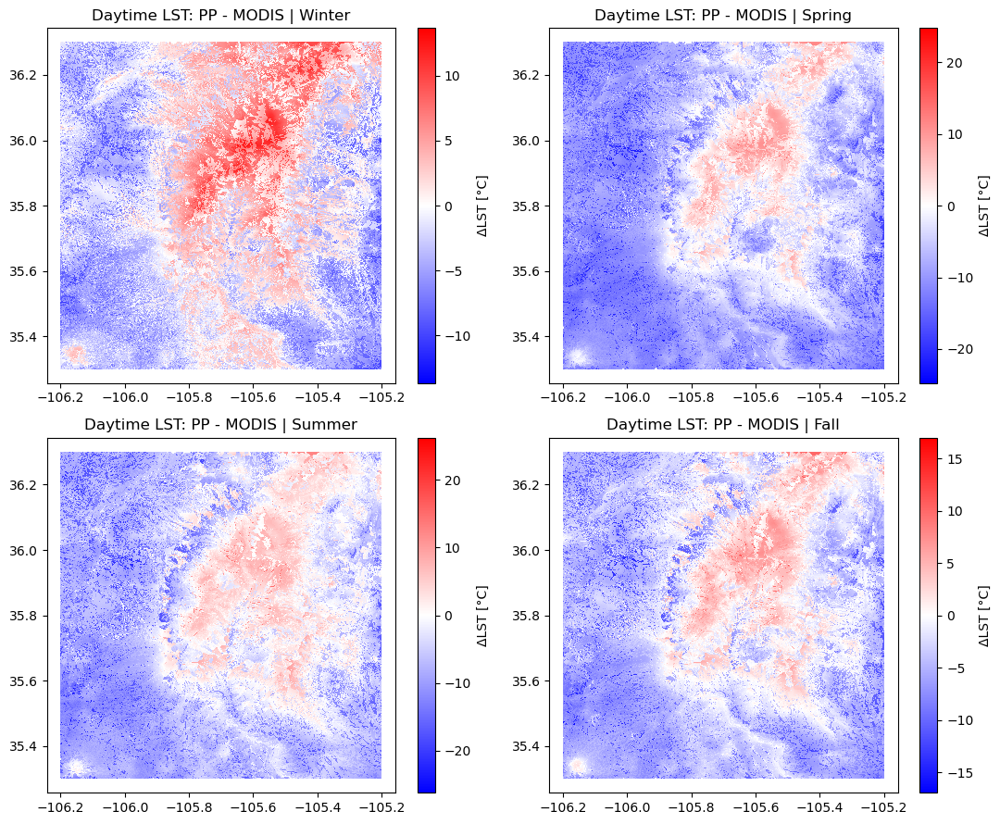

In [27]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import rasterio
from osgeo import gdal
import geospatialtools.gdal_tools as gdal_tools

# -------------------------------------------------
# Paths
# -------------------------------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"
modis_dir = "/scratch/alpine/battobrah@xsede.org/MODIS_on_HBgrid_new/"
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/Surface_Temp_Plots"
os.makedirs(outputdir, exist_ok=True)

# -------------------------------------------------
# Read model time and convert to local time
# -------------------------------------------------
fp = nc.Dataset(path_pp + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]   # hours since start
fp.close()

start = pd.Timestamp("2016-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# -------------------------------------------------
# Read HB rasters and coordinates
# -------------------------------------------------
hrus = gdal_tools.read_raster(path_pp + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path_pp + "postprocess/hrus.vrt")

with rasterio.open(path_pp + "postprocess/cids.vrt") as ds:
    cids = ds.read(1)

buffer = 250
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# -------------------------------------------------
# Helper: map HRU values to raster grid
# -------------------------------------------------
def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out

# -------------------------------------------------
# Read PP trad and cosz once
# -------------------------------------------------
with nc.Dataset(path_pp + "output_data/1/2016-01-01.nc") as fp:
    grp = fp.groups["data"]
    trad_pp = np.array(grp.variables["trad"][:])   # Kelvin
    cosz_pp = np.array(grp.variables["cosz"][:])

# -------------------------------------------------
# Seasons and MODIS month mapping
# -------------------------------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

# -------------------------------------------------
# MODIS helper: read daytime band (Band 1 = LST_Day_C)
# -------------------------------------------------
def read_modis_day_file(year, month):
    f = os.path.join(modis_dir, f"MOD11A1_monthly_mean_{year}_{month:02d}.tif")
    ds = gdal.Open(f)
    if ds is None:
        raise FileNotFoundError(f"Could not open {f}")

    band = ds.GetRasterBand(1)  # Band 1 = LST_Day_C
    arr = band.ReadAsArray().astype(float)
    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan
    return arr

# -------------------------------------------------
# Build 2016-2018 seasonal MODIS daytime climatology
# -------------------------------------------------
def seasonal_modis_mean(season_name):
    months = season_months[season_name]
    stack = []

    for year in [2016, 2017, 2018]:
        for month in months:
            # Winter handling:
            # Dec belongs to same calendar year used in your monthly archive.
            # So for 2016-2018 seasonal climatology, this uses Dec 2016/2017/2018,
            # Jan 2016/2017/2018, Feb 2016/2017/2018.
            arr = read_modis_day_file(year, month)
            stack.append(arr)

    return np.nanmean(np.stack(stack, axis=0), axis=0)

# -------------------------------------------------
# Plot PP daytime seasonal LST minus MODIS daytime seasonal LST
# -------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[my_season]

    print(f"Creating PP - MODIS daytime LST difference plot for {my_season}")

    # -------------------------
    # PP daytime seasonal mean
    # -------------------------
    season_mask = times.dt.month.isin(my_months).values
    day_mask = cosz_pp > 0.3
    mask_pp = season_mask[:, None] & day_mask

    trad_pp_day = np.where(mask_pp, trad_pp, np.nan) - 273.15   # convert K to C
    trad_pp_ave = np.nanmean(trad_pp_day, axis=0)               # (hru,)

    map_pp = place_data(tmp, trad_pp_ave, hrus, cids, 1)
    map_pp = np.where(map_pp == -9999, np.nan, map_pp)

    # crop PP
    shape_pp = map_pp.shape
    map_pp = map_pp[
        buffer:shape_pp[0] - buffer + 1,
        buffer:shape_pp[1] - buffer + 1
    ]

    # -------------------------
    # MODIS daytime seasonal mean
    # -------------------------
    modis_season = seasonal_modis_mean(my_season)

    shape_modis = modis_season.shape
    modis_season = modis_season[
        buffer:shape_modis[0] - buffer + 1,
        buffer:shape_modis[1] - buffer + 1
    ]

    # shape check
    if map_pp.shape != modis_season.shape:
        raise ValueError(f"Shape mismatch: PP {map_pp.shape}, MODIS {modis_season.shape}")

    # -------------------------
    # Difference: PP - MODIS
    # positive => model warmer
    # negative => model colder
    # -------------------------
    final_map = map_pp - modis_season

    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue

    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="bwr",
        norm=diff_norm,
        shading="auto"
    )

    ax.set_title(f"Daytime LST: PP - MODIS | {my_season}")
    fig.colorbar(im, ax=ax, label="ΔLST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_daytime_LST_PP_minus_MODIS_seasonal.png"),
    dpi=300
)
plt.show()

PP vs MODIS daytime LST: Winter
PP vs MODIS daytime LST: Spring
PP vs MODIS daytime LST: Summer
PP vs MODIS daytime LST: Fall


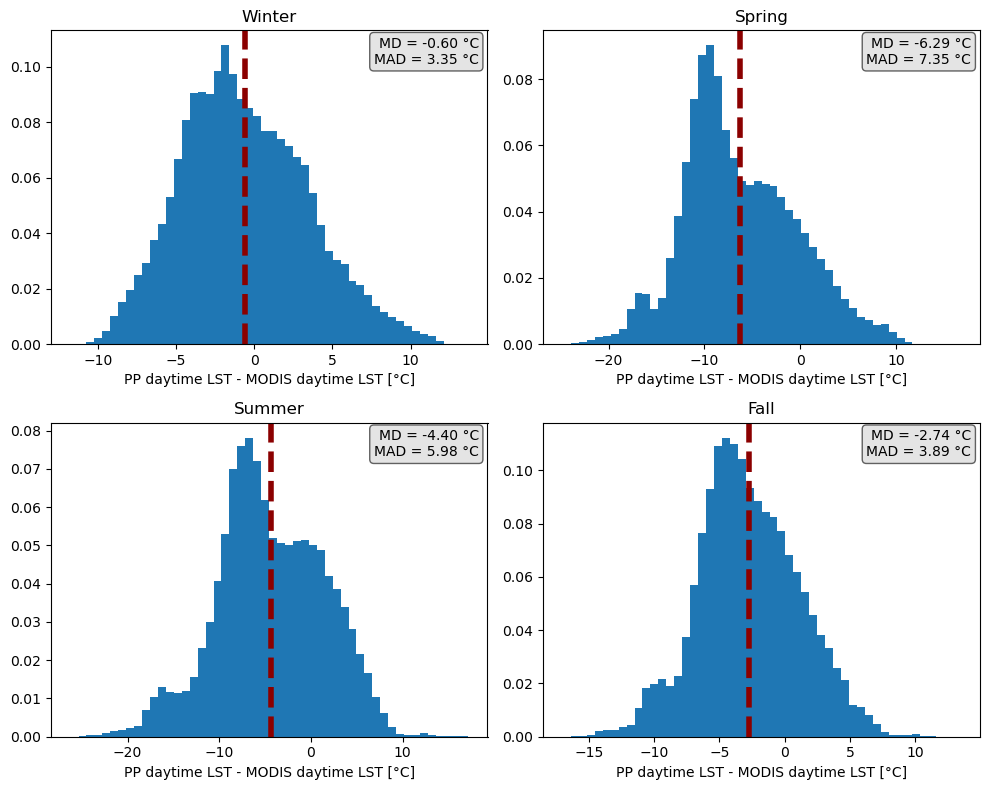

In [28]:
# PP vs MODIS difference Histogram Plot (Daytime land surface temperature)
# Difference = PP daytime LST - MODIS daytime LST

path_domain = path_pp  # use PP domain for mapping

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# read PP outputs once
fp_pp = nc.Dataset(path_pp + "output_data/1/2016-01-01.nc")
trad_pp = np.array(fp_pp.groups["data"].variables["trad"][:])  # (time, hru), K
cosz_pp = np.array(fp_pp.groups["data"].variables["cosz"][:])  # (time, hru)
fp_pp.close()

# helper: read daytime MODIS band (Band 1 = LST_Day_C)
def read_modis_day_file(year, month):
    f = os.path.join(modis_dir, f"MOD11A1_monthly_mean_{year}_{month:02d}.tif")
    ds = gdal.Open(f)
    if ds is None:
        raise FileNotFoundError(f"Could not open {f}")

    band = ds.GetRasterBand(1)  # Band 1 = LST_Day_C
    arr = band.ReadAsArray().astype(float)
    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan
    return arr

# helper: seasonal MODIS daytime mean
def seasonal_modis_mean(season_name):
    months = season_months[season_name]
    stack = []

    for year in [2016, 2017, 2018]:
        for month in months:
            arr = read_modis_day_file(year, month)
            stack.append(arr)

    return np.nanmean(np.stack(stack, axis=0), axis=0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[my_season]

    print(f"PP vs MODIS daytime LST: {my_season}")

    # -------------------------
    # PP seasonal daytime mean LST (HRU)
    # -------------------------
    idx = times.dt.month.isin(my_months).to_numpy()

    mask_pp = idx[:, None] & (cosz_pp > 0.3)
    trad_pp_day = np.where(mask_pp, trad_pp, np.nan) - 273.15
    trad_pp_mean = np.nanmean(trad_pp_day, axis=0)

    # map PP HRU -> grid
    trad_pp_grid = place_data(tmp, trad_pp_mean, hrus, cids, 1)
    trad_pp_grid = np.where(trad_pp_grid == -9999, np.nan, trad_pp_grid)
    trad_pp_grid = trad_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # MODIS seasonal daytime mean (grid)
    # -------------------------
    modis_grid = seasonal_modis_mean(my_season)
    modis_grid = modis_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # difference + histogram
    # -------------------------
    
    diff = trad_pp_grid - modis_grid
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    md = np.mean(arr)
    mad = np.mean(np.abs(arr))

    ax.text(
        0.98, 0.98,
        f"MD = {md:.2f} °C\nMAD = {mad:.2f} °C",
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
        boxstyle="round",
        facecolor="lightgray",
        edgecolor="black",
        alpha=0.6
        )
    )

    ax.set_title(my_season)
    ax.set_xlabel("PP daytime LST - MODIS daytime LST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_trad_daytime_PP_minus_MODIS.png"),
    dpi=300
)
plt.show()

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
MODIS: /scratch/alpine/battobrah@xsede.org/MODIS_on_HBgrid_new
Creating differences plot for Winter
Creating differences plot for Spring
Creating differences plot for Summer
Creating differences plot for Fall


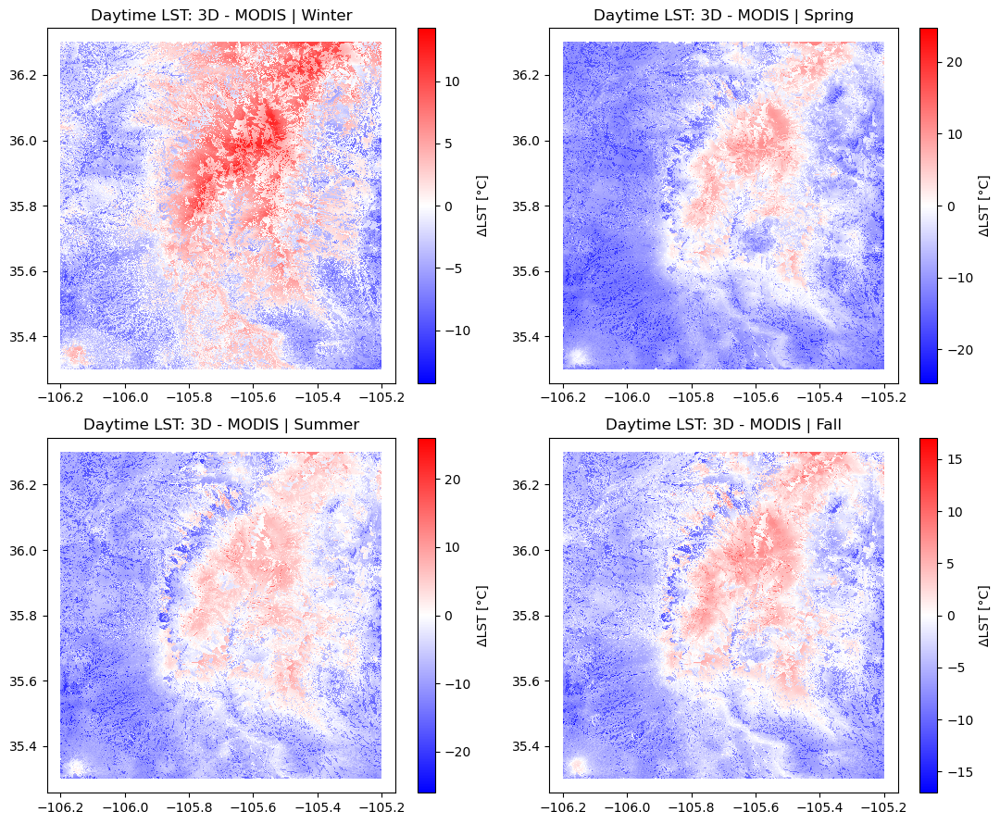

In [29]:
# 3D - MODIS seasonal difference maps (Daytime LST)
# Difference = 3D daytime trad - MODIS daytime LST

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from osgeo import gdal

print("3D:", path_3d)
modis_sat = "/scratch/alpine/battobrah@xsede.org/MODIS_on_HBgrid_new"
print("MODIS:", modis_sat)

# use 3D domain for mapping
path = path_3d

# read mapping rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# MODIS monthly files
pat = re.compile(r"MOD11A1_monthly_mean_(\d{4})_(\d{2})\.tif$")

def build_modis_rows(modis_folder):
    files = sorted(glob.glob(os.path.join(modis_folder, "*.tif")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyy = int(m.group(1))
        mm = int(m.group(2))
        dt = pd.Timestamp(yyyy, mm, 1)
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows.sort(key=lambda x: x[0])
    if not rows:
        raise RuntimeError(f"No MODIS monthly files matched for 2016–2018 in: {modis_folder}")
    return rows

def read_modis_day_grid(fp):
    ds = gdal.Open(fp)
    if ds is None:
        raise RuntimeError(f"Could not open {fp}")

    band = ds.GetRasterBand(1)   # Band 1 = LST_Day_C
    arr = band.ReadAsArray().astype("float32")

    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan

    return arr

def modis_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_modis_day_grid(fp))   # MODIS already on HB/model grid
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

modis_rows = build_modis_rows(modis_sat)

# read 3D model outputs once
fp_3d = nc.Dataset(path_3d + "output_data/1/2016-01-01.nc")
grp_3d = fp_3d.groups["data"]
trad_3d = np.array(grp_3d.variables["trad"][:])   # (time, hru), Kelvin
cosz_3d = np.array(grp_3d.variables["cosz"][:])   # (time, hru)
fp_3d.close()

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print(f"Creating differences plot for {my_season}")

    # 3D model seasonal daytime mean trad in HRU space
    times_index = (
        (times.dt.month == my_months[0]) |
        (times.dt.month == my_months[1]) |
        (times.dt.month == my_months[2])
    ).values

    day_mask = cosz_3d > 0.3
    mask_3d = times_index[:, None] & day_mask

    trad_3d_sel = np.where(mask_3d, trad_3d, np.nan) - 273.15   # K -> C
    trad_3d_ave = np.nanmean(trad_3d_sel, axis=0)               # (hru,)

    # map model HRU -> grid
    map_3d = place_data(tmp, trad_3d_ave, hrus, cids, 1)
    map_3d = np.where(map_3d == -9999, np.nan, map_3d)

    # MODIS seasonal mean on model grid
    modis_map = modis_season_mean(modis_rows, my_months)
    if modis_map is None:
        ax.axis("off")
        continue

    # remove buffer
    map_shape = map_3d.shape
    map_3d = map_3d[
        buffer:map_shape[0]-buffer+1,
        buffer:map_shape[1]-buffer+1
    ]
    modis_map = modis_map[
        buffer:modis_map.shape[0]-buffer+1,
        buffer:modis_map.shape[1]-buffer+1
    ]

    # valid comparison mask
    valid = np.isfinite(map_3d) & np.isfinite(modis_map)
    final_map = np.where(valid, map_3d - modis_map, np.nan)

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue

    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    cmap = plt.cm.bwr.copy()
    cmap.set_bad(color="white")

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap=cmap,
        norm=diff_norm,
        shading="auto"
    )

    ax.set_title(f"Daytime LST: 3D - MODIS | {my_season}")
    fig.colorbar(im, ax=ax, label="ΔLST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_daytime_LST_3d_minus_MODIS_maps.png"),
    dpi=300
)
plt.show()

3D vs MODIS daytime LST: Winter
3D vs MODIS daytime LST: Spring
3D vs MODIS daytime LST: Summer
3D vs MODIS daytime LST: Fall


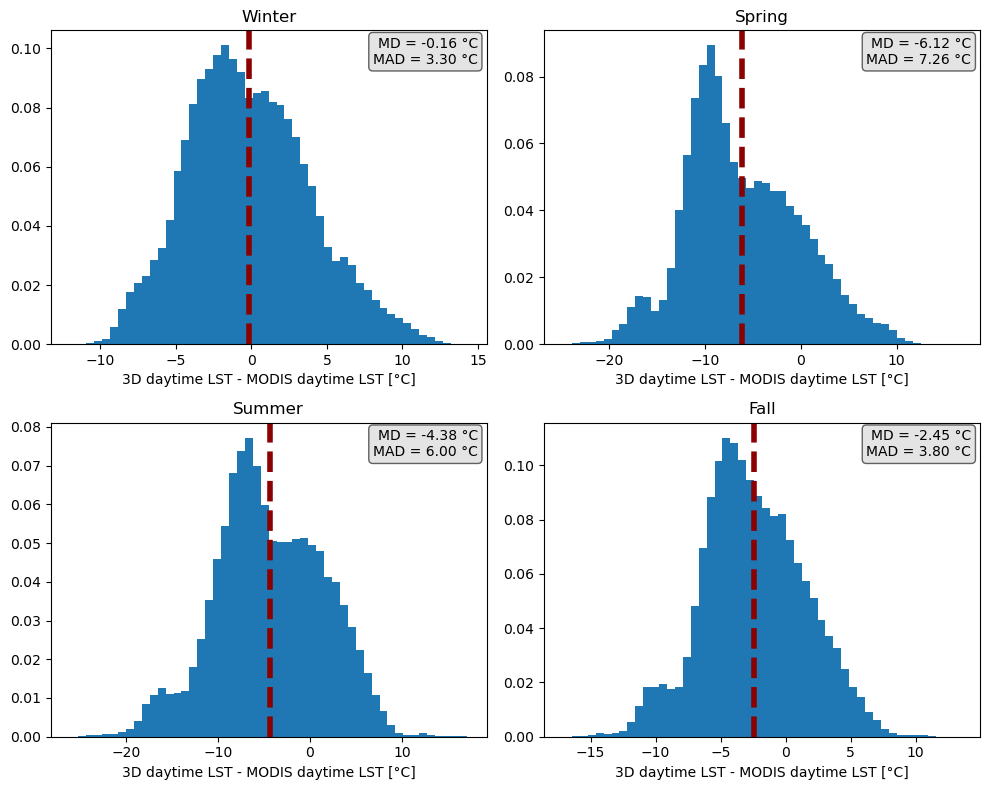

In [30]:
# 3D vs MODIS difference Histogram Plot (Daytime land surface temperature)
# Difference = 3D daytime LST - MODIS daytime LST

path_domain = path_3d  # use 3D domain for mapping

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# read 3D outputs once
fp_3d = nc.Dataset(path_3d + "output_data/1/2016-01-01.nc")
trad_3d = np.array(fp_3d.groups["data"].variables["trad"][:])  # (time, hru), K
cosz_3d = np.array(fp_3d.groups["data"].variables["cosz"][:])  # (time, hru)
fp_3d.close()

# helper: read daytime MODIS band (Band 1 = LST_Day_C)
def read_modis_day_file(year, month):
    f = os.path.join(modis_dir, f"MOD11A1_monthly_mean_{year}_{month:02d}.tif")
    ds = gdal.Open(f)
    if ds is None:
        raise FileNotFoundError(f"Could not open {f}")

    band = ds.GetRasterBand(1)  # Band 1 = LST_Day_C
    arr = band.ReadAsArray().astype(float)
    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan
    return arr

# helper: seasonal MODIS daytime mean
def seasonal_modis_mean(season_name):
    months = season_months[season_name]
    stack = []

    for year in [2016, 2017, 2018]:
        for month in months:
            arr = read_modis_day_file(year, month)
            stack.append(arr)

    return np.nanmean(np.stack(stack, axis=0), axis=0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[my_season]

    print(f"3D vs MODIS daytime LST: {my_season}")

    # -------------------------
    # 3D seasonal daytime mean LST (HRU)
    # -------------------------
    idx = times.dt.month.isin(my_months).to_numpy()

    mask_3d = idx[:, None] & (cosz_3d > 0.3)
    trad_3d_day = np.where(mask_3d, trad_3d, np.nan) - 273.15
    trad_3d_mean = np.nanmean(trad_3d_day, axis=0)

    # map 3D HRU -> grid
    trad_3d_grid = place_data(tmp, trad_3d_mean, hrus, cids, 1)
    trad_3d_grid = np.where(trad_3d_grid == -9999, np.nan, trad_3d_grid)
    trad_3d_grid = trad_3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # MODIS seasonal daytime mean (grid)
    # -------------------------
    modis_grid = seasonal_modis_mean(my_season)
    modis_grid = modis_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # difference + histogram
    # -------------------------
    valid = np.isfinite(trad_3d_grid) & np.isfinite(modis_grid)
    arr = (trad_3d_grid - modis_grid)[valid]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    md = np.mean(arr)
    mad = np.mean(np.abs(arr))

    ax.text(
        0.98, 0.98,
        f"MD = {md:.2f} °C\nMAD = {mad:.2f} °C",
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
        boxstyle="round",
        facecolor="lightgray",
        edgecolor="black",
        alpha=0.6
        )
    )
    ax.set_title(my_season)
    ax.set_xlabel("3D daytime LST - MODIS daytime LST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_trad_daytime_3D_minus_MODIS.png"),
    dpi=300
)
plt.show()

In [18]:
print("PP NaNs:", np.isnan(map_pp).sum())
print("MODIS NaNs:", np.isnan(modis_season).sum())
print("Final NaNs:", np.isnan(final_map).sum())

PP NaNs: 253358
MODIS NaNs: 0
Final NaNs: 253358


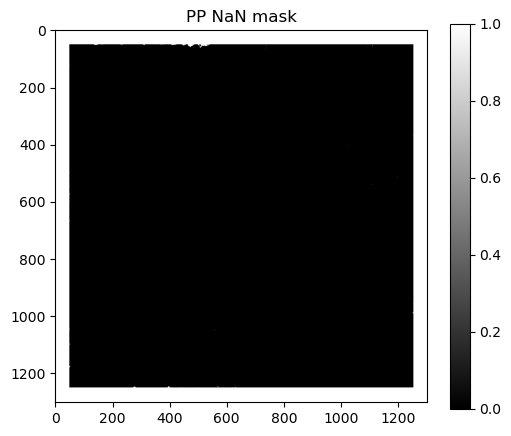

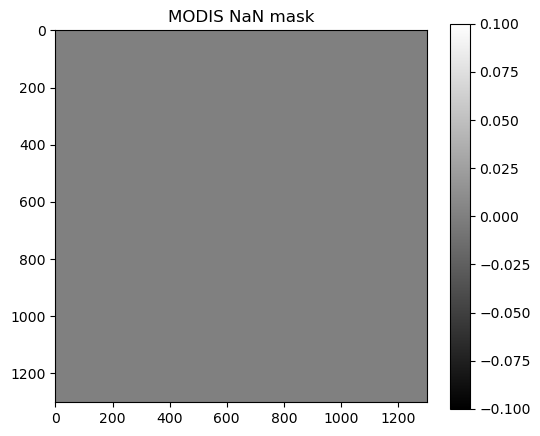

In [19]:
plt.figure(figsize=(6,5))
plt.imshow(np.isnan(map_pp), origin="upper", cmap="gray")
plt.title("PP NaN mask")
plt.colorbar()
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(np.isnan(modis_season), origin="upper", cmap="gray")
plt.title("MODIS NaN mask")
plt.colorbar()
plt.show()

3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
MODIS: /scratch/alpine/battobrah@xsede.org/MODIS_on_HBgrid_new
Creating nighttime differences plot for Winter
Creating nighttime differences plot for Spring
Creating nighttime differences plot for Summer
Creating nighttime differences plot for Fall


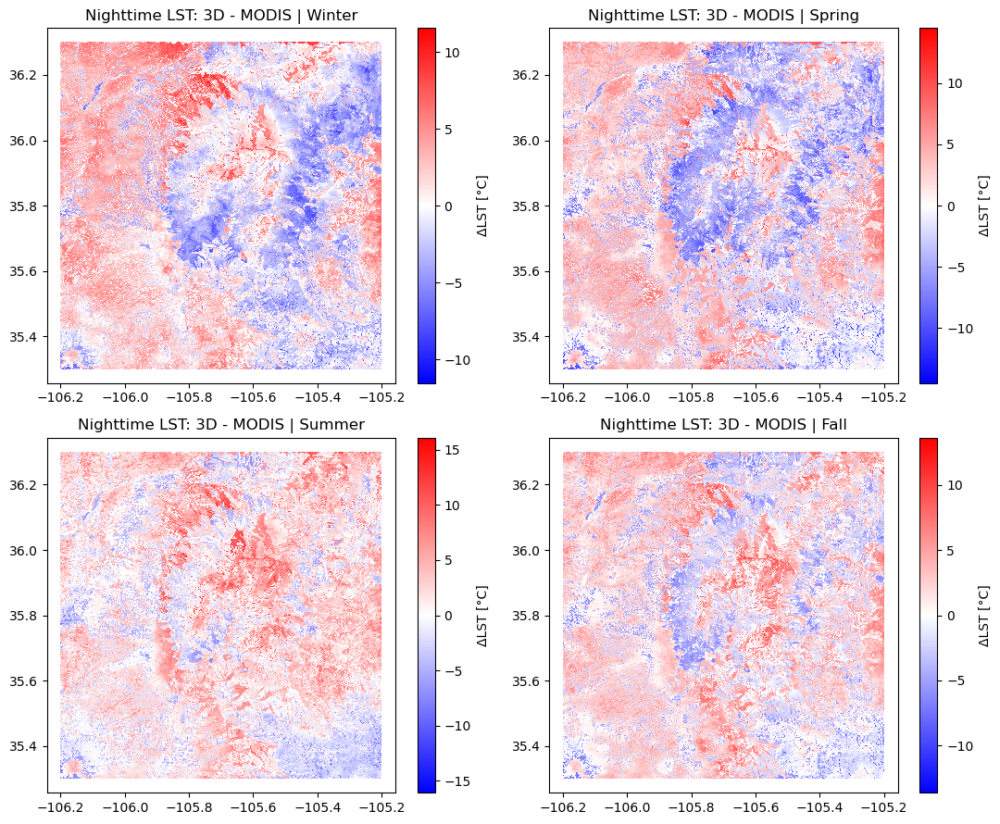

In [31]:
# 3D - MODIS seasonal difference maps (Nighttime LST)
# Difference = 3D nighttime trad - MODIS nighttime LST

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from osgeo import gdal

print("3D:", path_3d)
modis_dir = "/scratch/alpine/battobrah@xsede.org/MODIS_on_HBgrid_new/"
print("MODIS:", modis_sat)

# use 3D domain for mapping
path = path_3d

# read mapping rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# MODIS monthly files
pat = re.compile(r"MOD11A1_monthly_mean_(\d{4})_(\d{2})\.tif$")

def build_modis_rows(modis_folder):
    files = sorted(glob.glob(os.path.join(modis_folder, "*.tif")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyy = int(m.group(1))
        mm = int(m.group(2))
        dt = pd.Timestamp(yyyy, mm, 1)
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows.sort(key=lambda x: x[0])
    if not rows:
        raise RuntimeError(f"No MODIS monthly files matched for 2016–2018 in: {modis_folder}")
    return rows

def read_modis_night_grid(fp):
    ds = gdal.Open(fp)
    if ds is None:
        raise RuntimeError(f"Could not open {fp}")

    band = ds.GetRasterBand(2)   # Band 2 = LST_Night_C
    arr = band.ReadAsArray().astype("float32")

    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan

    return arr

def modis_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_modis_night_grid(fp))   # MODIS already on HB/model grid
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

modis_rows = build_modis_rows(modis_sat)

# read 3D model outputs once
fp_3d = nc.Dataset(path_3d + "output_data/1/2016-01-01.nc")
grp_3d = fp_3d.groups["data"]
trad_3d = np.array(grp_3d.variables["trad"][:])   # (time, hru), Kelvin
cosz_3d = np.array(grp_3d.variables["cosz"][:])   # (time, hru)
fp_3d.close()

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print(f"Creating nighttime differences plot for {my_season}")

    # 3D model seasonal nighttime mean trad in HRU space
    times_index = (
        (times.dt.month == my_months[0]) |
        (times.dt.month == my_months[1]) |
        (times.dt.month == my_months[2])
    ).values

    night_mask = cosz_3d < 0
    mask_3d = times_index[:, None] & night_mask

    trad_3d_sel = np.where(mask_3d, trad_3d, np.nan) - 273.15   # K -> C
    trad_3d_ave = np.nanmean(trad_3d_sel, axis=0)               # (hru,)

    # map model HRU -> grid
    map_3d = place_data(tmp, trad_3d_ave, hrus, cids, 1)
    map_3d = np.where(map_3d == -9999, np.nan, map_3d)

    # MODIS seasonal mean on model grid
    modis_map = modis_season_mean(modis_rows, my_months)
    if modis_map is None:
        ax.axis("off")
        continue

    # remove buffer
    map_shape = map_3d.shape
    map_3d = map_3d[
        buffer:map_shape[0]-buffer+1,
        buffer:map_shape[1]-buffer+1
    ]
    modis_map = modis_map[
        buffer:modis_map.shape[0]-buffer+1,
        buffer:modis_map.shape[1]-buffer+1
    ]

    # valid comparison mask
    valid = np.isfinite(map_3d) & np.isfinite(modis_map)
    final_map = np.where(valid, map_3d - modis_map, np.nan)

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue

    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    cmap = plt.cm.bwr.copy()
    cmap.set_bad(color="white")

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap=cmap,
        norm=diff_norm,
        shading="auto"
    )

    ax.set_title(f"Nighttime LST: 3D - MODIS | {my_season}")
    fig.colorbar(im, ax=ax, label="ΔLST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_nighttime_LST_3d_minus_MODIS_maps.png"),
    dpi=300
)
plt.show()

3D vs MODIS nighttime LST: Winter
3D vs MODIS nighttime LST: Spring
3D vs MODIS nighttime LST: Summer
3D vs MODIS nighttime LST: Fall


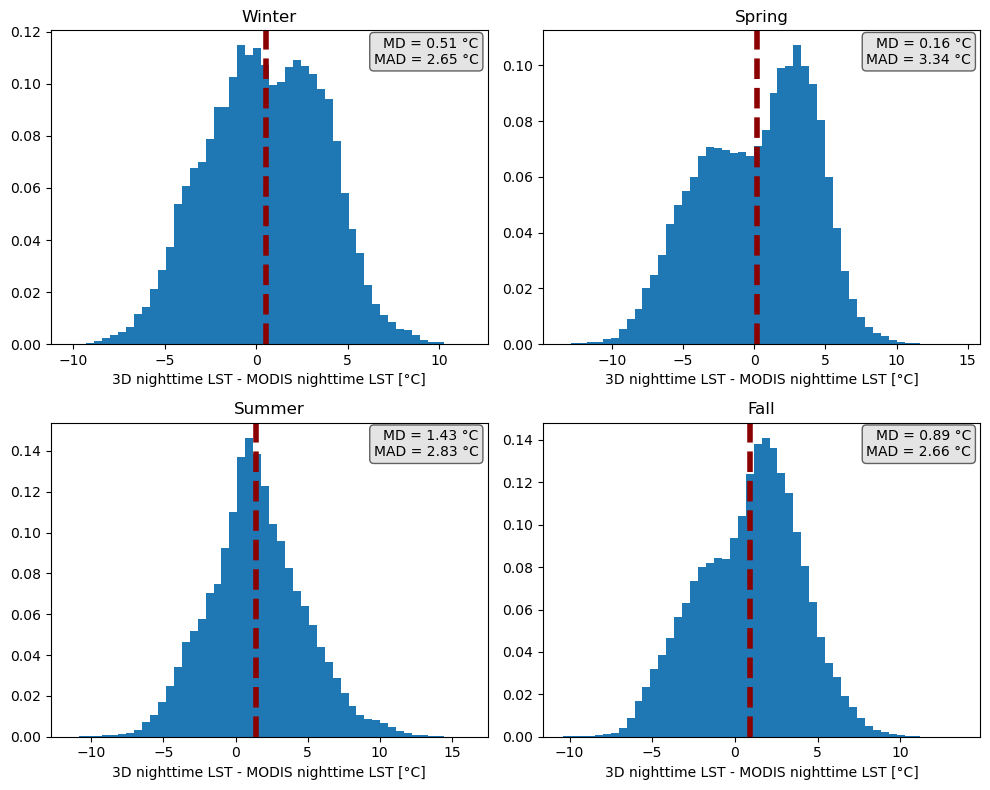

In [32]:
# 3D vs MODIS difference Histogram Plot (Nighttime land surface temperature)
# Difference = 3D nighttime LST - MODIS nighttime LST

path_domain = path_3d  # use 3D domain for mapping

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# read 3D outputs once
fp_3d = nc.Dataset(path_3d + "output_data/1/2016-01-01.nc")
trad_3d = np.array(fp_3d.groups["data"].variables["trad"][:])  # (time, hru), K
cosz_3d = np.array(fp_3d.groups["data"].variables["cosz"][:])  # (time, hru)
fp_3d.close()

# helper: read nighttime MODIS band (Band 2 = LST_Night_C)
def read_modis_night_file(year, month):
    f = os.path.join(modis_dir, f"MOD11A1_monthly_mean_{year}_{month:02d}.tif")
    ds = gdal.Open(f)
    if ds is None:
        raise FileNotFoundError(f"Could not open {f}")

    band = ds.GetRasterBand(2)  # Band 2 = LST_Night_C
    arr = band.ReadAsArray().astype(float)
    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan
    return arr

# helper: seasonal MODIS nighttime mean
def seasonal_modis_mean(season_name):
    months = season_months[season_name]
    stack = []

    for year in [2016, 2017, 2018]:
        for month in months:
            arr = read_modis_night_file(year, month)
            stack.append(arr)

    return np.nanmean(np.stack(stack, axis=0), axis=0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[my_season]

    print(f"3D vs MODIS nighttime LST: {my_season}")

    # -------------------------
    # 3D seasonal nighttime mean LST (HRU)
    # -------------------------
    idx = times.dt.month.isin(my_months).to_numpy()

    mask_3d = idx[:, None] & (cosz_3d < 0)
    trad_3d_night = np.where(mask_3d, trad_3d, np.nan) - 273.15
    trad_3d_mean = np.nanmean(trad_3d_night, axis=0)

    # map 3D HRU -> grid
    trad_3d_grid = place_data(tmp, trad_3d_mean, hrus, cids, 1)
    trad_3d_grid = np.where(trad_3d_grid == -9999, np.nan, trad_3d_grid)
    trad_3d_grid = trad_3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # MODIS seasonal nighttime mean (grid)
    # -------------------------
    modis_grid = seasonal_modis_mean(my_season)
    modis_grid = modis_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # difference + histogram
    # -------------------------
    valid = np.isfinite(trad_3d_grid) & np.isfinite(modis_grid)
    arr = (trad_3d_grid - modis_grid)[valid]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    md = np.mean(arr)
    mad = np.mean(np.abs(arr))

    ax.text(
        0.98, 0.98,
        f"MD = {md:.2f} °C\nMAD = {mad:.2f} °C",
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            boxstyle="round",
            facecolor="lightgray",
            edgecolor="black",
            alpha=0.6
        )
    )

    ax.set_title(my_season)
    ax.set_xlabel("3D nighttime LST - MODIS nighttime LST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_trad_nighttime_3D_minus_MODIS.png"),
    dpi=300
)
plt.show()

PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/
MODIS: /scratch/alpine/battobrah@xsede.org/MODIS_on_HBgrid_new
Creating differences plot for Winter
Creating differences plot for Spring
Creating differences plot for Summer
Creating differences plot for Fall


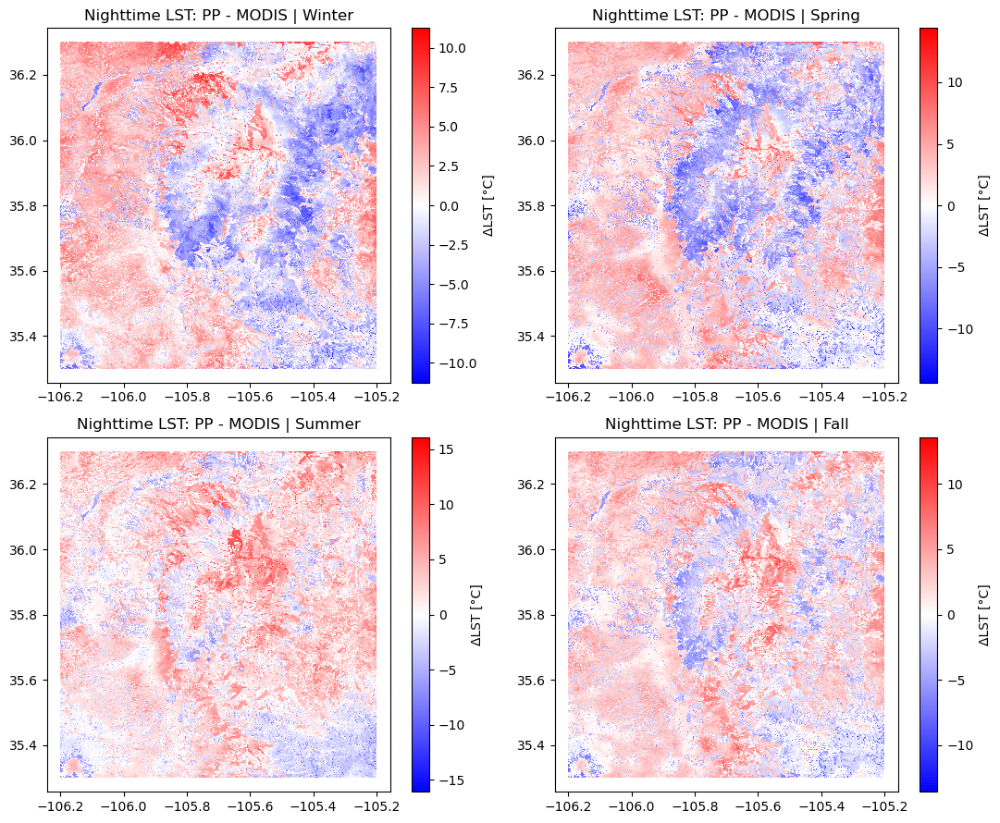

In [33]:
# PP - MODIS seasonal difference maps (Nighttime LST)
# Difference = PP nighttime trad - MODIS nighttime LST

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from osgeo import gdal

print("PP:", path_pp)
modis_sat = "/scratch/alpine/battobrah@xsede.org/MODIS_on_HBgrid_new"
print("MODIS:", modis_sat)

# use PP domain for mapping
path = path_pp

# read mapping rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# MODIS monthly files
pat = re.compile(r"MOD11A1_monthly_mean_(\d{4})_(\d{2})\.tif$")

def build_modis_rows(modis_folder):
    files = sorted(glob.glob(os.path.join(modis_folder, "*.tif")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyy = int(m.group(1))
        mm = int(m.group(2))
        dt = pd.Timestamp(yyyy, mm, 1)
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows.sort(key=lambda x: x[0])
    if not rows:
        raise RuntimeError(f"No MODIS monthly files matched for 2016–2018 in: {modis_folder}")
    return rows

def read_grid(fp):
    ds = gdal.Open(fp)
    if ds is None:
        raise RuntimeError(f"Could not open {fp}")

    band = ds.GetRasterBand(2)   # Band 2 = LST_Night_C
    arr = band.ReadAsArray().astype("float32")

    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan

    return arr

def modis_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_grid(fp))  # MODIS already on HydroBlocks/model grid
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

modis_rows = build_modis_rows(modis_sat)

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # PP model seasonal nighttime mean trad in HRU space
    fp_pp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    grp_pp = fp_pp.groups["data"]
    trad_pp = np.array(grp_pp.variables["trad"][:])   # (time, hru), K
    cosz_pp = np.array(grp_pp.variables["cosz"][:])   # (time, hru)
    fp_pp.close()

    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    night_mask = cosz_pp < 0
    mask_pp = times_index.values[:, None] & night_mask

    trad_pp_sel = np.where(mask_pp, trad_pp, np.nan) - 273.15
    trad_pp_ave = np.nanmean(trad_pp_sel, axis=0)   # (hru,)

    # map model HRU -> grid
    map_pp = place_data(tmp, trad_pp_ave, hrus, cids, 1)
    map_pp = np.ma.masked_array(map_pp, map_pp == -9999)
    map_pp[map_pp == -9999] = np.nan

    # MODIS seasonal mean on model grid
    modis_map = modis_season_mean(modis_rows, my_months)
    if modis_map is None:
        ax.axis("off")
        continue

    # remove buffer
    map_shape = map_pp.shape
    map_pp = map_pp[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    modis_map = modis_map[buffer:modis_map.shape[0]-buffer+1, buffer:modis_map.shape[1]-buffer+1]

    # difference: PP - MODIS
    final_map = map_pp - modis_map

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("Nighttime LST: PP - MODIS | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔLST [°C]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_nighttime_PP_minus_MODIS_LST_maps.png"), dpi=300)
plt.show()

PP vs MODIS nighttime LST: Winter
PP vs MODIS nighttime LST: Spring
PP vs MODIS nighttime LST: Summer
PP vs MODIS nighttime LST: Fall


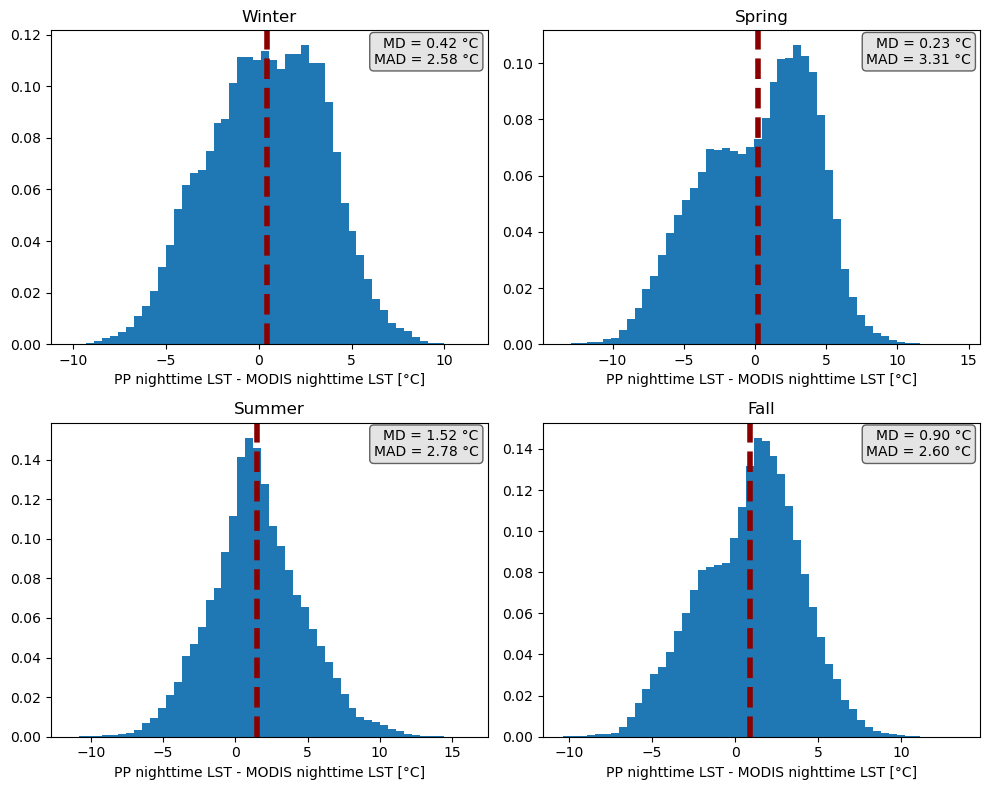

In [34]:
# PP vs MODIS difference Histogram Plot (Nighttime land surface temperature)
# Difference = PP nighttime LST - MODIS nighttime LST

path_domain = path_pp  # use PP domain for mapping

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# read PP outputs once
fp_pp = nc.Dataset(path_pp + "output_data/1/2016-01-01.nc")
trad_pp = np.array(fp_pp.groups["data"].variables["trad"][:])  # (time, hru), K
cosz_pp = np.array(fp_pp.groups["data"].variables["cosz"][:])  # (time, hru)
fp_pp.close()

# helper: read nighttime MODIS band (Band 2 = LST_Night_C)
def read_modis_night_file(year, month):
    f = os.path.join(modis_dir, f"MOD11A1_monthly_mean_{year}_{month:02d}.tif")
    ds = gdal.Open(f)
    if ds is None:
        raise FileNotFoundError(f"Could not open {f}")

    band = ds.GetRasterBand(2)  # Band 2 = LST_Night_C
    arr = band.ReadAsArray().astype(float)
    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan
    return arr

# helper: seasonal MODIS nighttime mean
def seasonal_modis_mean(season_name):
    months = season_months[season_name]
    stack = []

    for year in [2016, 2017, 2018]:
        for month in months:
            arr = read_modis_night_file(year, month)
            stack.append(arr)

    return np.nanmean(np.stack(stack, axis=0), axis=0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[my_season]

    print(f"PP vs MODIS nighttime LST: {my_season}")

    # -------------------------
    # PP seasonal nighttime mean LST (HRU)
    # -------------------------
    idx = times.dt.month.isin(my_months).to_numpy()

    mask_pp = idx[:, None] & (cosz_pp < 0)
    trad_pp_night = np.where(mask_pp, trad_pp, np.nan) - 273.15
    trad_pp_mean = np.nanmean(trad_pp_night, axis=0)

    # map PP HRU -> grid
    trad_pp_grid = place_data(tmp, trad_pp_mean, hrus, cids, 1)
    trad_pp_grid = np.where(trad_pp_grid == -9999, np.nan, trad_pp_grid)
    trad_pp_grid = trad_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # MODIS seasonal nighttime mean (grid)
    # -------------------------
    modis_grid = seasonal_modis_mean(my_season)
    modis_grid = modis_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # difference + histogram
    # -------------------------
    valid = np.isfinite(trad_pp_grid) & np.isfinite(modis_grid)
    arr = (trad_pp_grid - modis_grid)[valid]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    md = np.mean(arr)
    mad = np.mean(np.abs(arr))

    ax.text(
        0.98, 0.98,
        f"MD = {md:.2f} °C\nMAD = {mad:.2f} °C",
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            boxstyle="round",
            facecolor="lightgray",
            edgecolor="black",
            alpha=0.6
        )
    )

    ax.set_title(my_season)
    ax.set_xlabel("PP nighttime LST - MODIS nighttime LST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_trad_nighttime_PP_minus_MODIS.png"),
    dpi=300
)
plt.show()

PP vs MODIS daytime LST: Winter
PP vs MODIS daytime LST: Spring
PP vs MODIS daytime LST: Summer
PP vs MODIS daytime LST: Fall


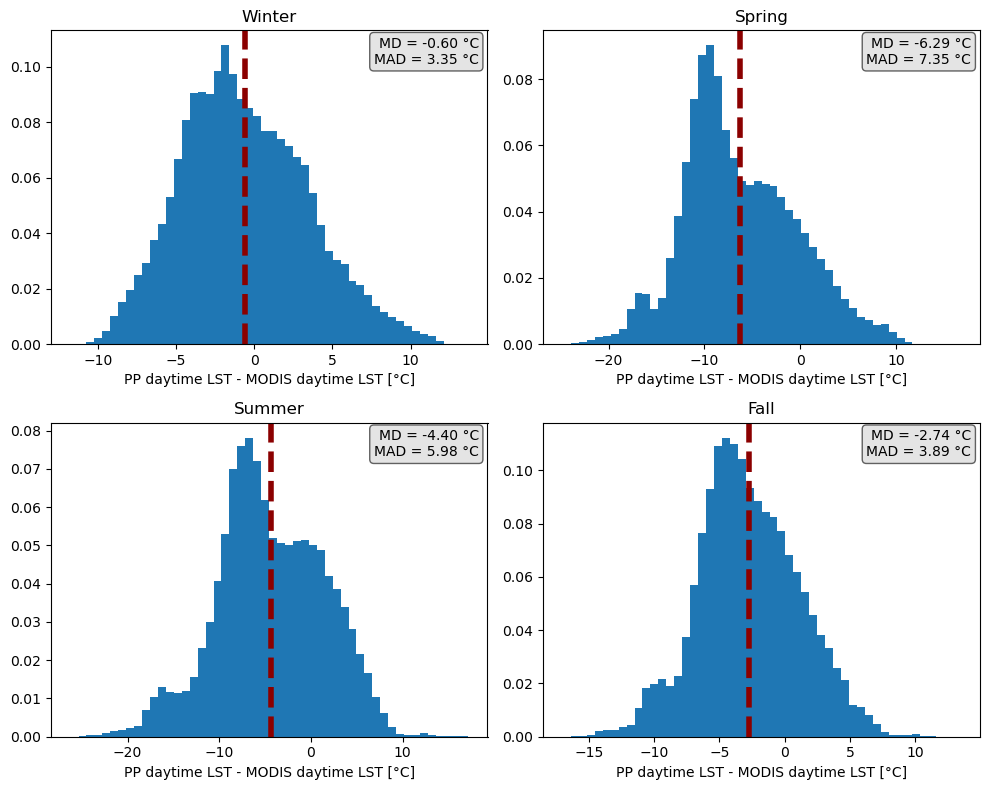

In [35]:
# PP vs MODIS difference Histogram Plot (Daytime land surface temperature)
# Difference = PP daytime LST - MODIS daytime LST

path_domain = path_pp  # use PP domain for mapping

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# read PP outputs once
fp_pp = nc.Dataset(path_pp + "output_data/1/2016-01-01.nc")
trad_pp = np.array(fp_pp.groups["data"].variables["trad"][:])  # (time, hru), K
cosz_pp = np.array(fp_pp.groups["data"].variables["cosz"][:])  # (time, hru)
fp_pp.close()

# helper: read daytime MODIS band (Band 1 = LST_Day_C)
def read_modis_day_file(year, month):
    f = os.path.join(modis_dir, f"MOD11A1_monthly_mean_{year}_{month:02d}.tif")
    ds = gdal.Open(f)
    if ds is None:
        raise FileNotFoundError(f"Could not open {f}")

    band = ds.GetRasterBand(1)  # Band 1 = LST_Day_C
    arr = band.ReadAsArray().astype(float)
    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan
    return arr

# helper: seasonal MODIS daytime mean
def seasonal_modis_mean(season_name):
    months = season_months[season_name]
    stack = []

    for year in [2016, 2017, 2018]:
        for month in months:
            arr = read_modis_day_file(year, month)
            stack.append(arr)

    return np.nanmean(np.stack(stack, axis=0), axis=0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[my_season]

    print(f"PP vs MODIS daytime LST: {my_season}")

    # -------------------------
    # PP seasonal daytime mean LST (HRU)
    # -------------------------
    idx = times.dt.month.isin(my_months).to_numpy()

    mask_pp = idx[:, None] & (cosz_pp > 0.3)
    trad_pp_day = np.where(mask_pp, trad_pp, np.nan) - 273.15
    trad_pp_mean = np.nanmean(trad_pp_day, axis=0)

    # map PP HRU -> grid
    trad_pp_grid = place_data(tmp, trad_pp_mean, hrus, cids, 1)
    trad_pp_grid = np.where(trad_pp_grid == -9999, np.nan, trad_pp_grid)
    trad_pp_grid = trad_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # MODIS seasonal daytime mean (grid)
    # -------------------------
    modis_grid = seasonal_modis_mean(my_season)
    modis_grid = modis_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # difference + histogram
    # -------------------------
    
    diff = trad_pp_grid - modis_grid
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    md = np.mean(arr)
    mad = np.mean(np.abs(arr))

    ax.text(
        0.98, 0.98,
        f"MD = {md:.2f} °C\nMAD = {mad:.2f} °C",
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
        boxstyle="round",
        facecolor="lightgray",
        edgecolor="black",
        alpha=0.6
        )
    )

    ax.set_title(my_season)
    ax.set_xlabel("PP daytime LST - MODIS daytime LST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_trad_daytime_PP_minus_MODIS.png"),
    dpi=300
)
plt.show()

In [25]:
import numpy as np
import netCDF4 as nc
import pandas as pd

# -----------------------------------
# Paths
# -----------------------------------
path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_downscale_new/"
path_3d = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/"

# -----------------------------------
# Read time from input file
# -----------------------------------
with nc.Dataset(path_pp + "1/input_file.nc") as fp:
    time = fp.groups["meteorology"]["time"][:]

start = pd.Timestamp("2016-01-01 00:00")
times = pd.Series(start + pd.to_timedelta(time, unit="h"), name="datetime")

# Read trad from both runs
with nc.Dataset(path_pp + "output_data/1/2016-01-01.nc") as ds:
    trad_pp = np.array(ds.groups["data"].variables["trad"][:], dtype=float)   # K

with nc.Dataset(path_3d + "output_data/1/2016-01-01.nc") as ds:
    trad_3d = np.array(ds.groups["data"].variables["trad"][:], dtype=float)   # K

# Check shapes
if trad_pp.shape != trad_3d.shape:
    raise ValueError(f"Shape mismatch: PP {trad_pp.shape}, 3D {trad_3d.shape}")

# Difference
diff = trad_3d - trad_pp   # K, same as C for differences

# Seasonal masks
season_defs = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
    "Annual": list(range(1, 13))
}

# Compute MD and MAD
results = []

for season, months in season_defs.items():
    mask = times.dt.month.isin(months).values

    pp_sel = trad_pp[mask, :]
    d3_sel = trad_3d[mask, :]
    dsel = diff[mask, :]

    pp_mean = np.nanmean(pp_sel)
    d3_mean = np.nanmean(d3_sel)
    md = np.nanmean(dsel)
    mad = np.nanmean(np.abs(dsel))

    results.append({
        "Season": season,
        "PP_mean_K": pp_mean,
        "3D_mean_K": d3_mean,
        "MD_K": md,
        "MAD_K": mad
    })

results_df = pd.DataFrame(results)
print(results_df)

   Season   PP_mean_K   3D_mean_K      MD_K     MAD_K
0     DJF  272.059362  272.215074  0.155711  0.458247
1     MAM  283.720747  283.655354 -0.065393  0.477849
2     JJA  295.016615  294.953988 -0.062627  0.354212
3     SON  284.272976  284.319311  0.046335  0.353473
4  Annual  283.851732  283.869159  0.017426  0.410757


3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_downscale_new/
MODIS: /scratch/alpine/battobrah@xsede.org/MODIS_on_HBgrid_new
Number of mapped HRUs: 1000
trad_3d shape: (8744, 1000)
cosz_3d shape: (8744, 1000)
Creating spatial difference plot for Winter
Winter 3D mean daytime LST = 5.49 C
Winter spatial mean difference = 0.69 C
Winter min/max difference = -11.49, 14.08 C
Creating spatial difference plot for Spring
Spring 3D mean daytime LST = 17.47 C
Spring spatial mean difference = -5.60 C
Spring min/max difference = -22.54, 12.68 C
Creating spatial difference plot for Summer
Summer 3D mean daytime LST = 30.02 C
Summer spatial mean difference = -3.82 C
Summer min/max difference = -22.83, 12.41 C
Creating spatial difference plot for Fall
Fall 3D mean daytime LST = 17.53 C
Fall spatial mean difference = -1.85 C
Fall min/max difference = -14.66, 10.02 C


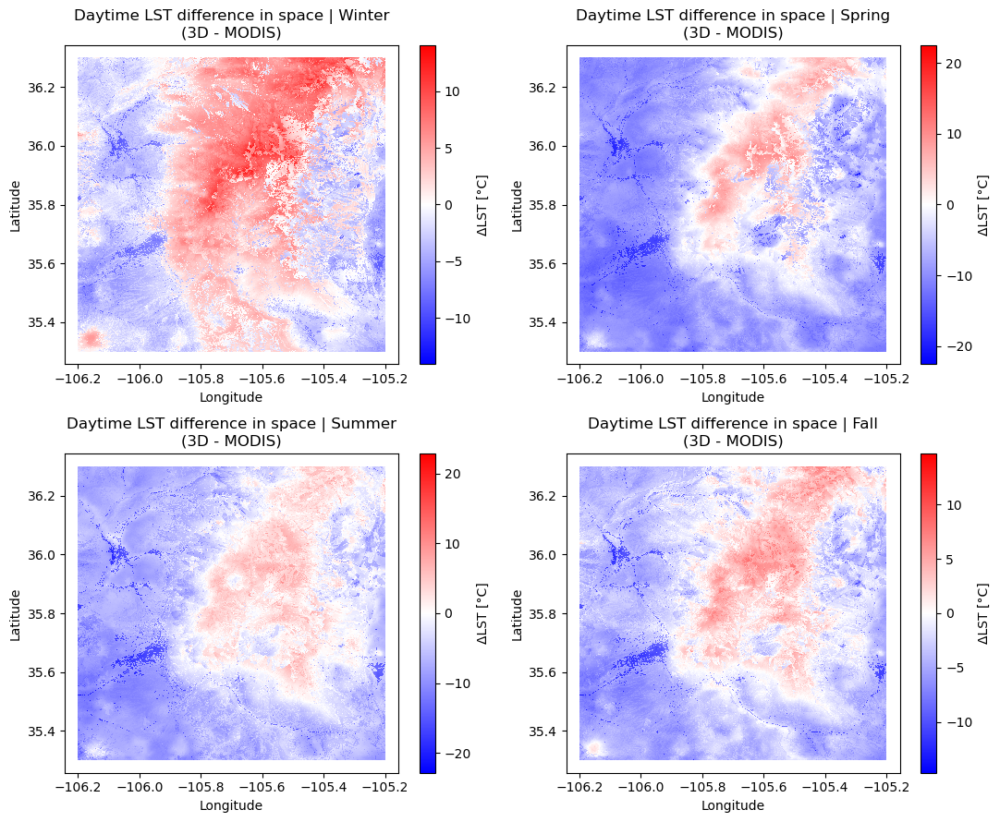

In [4]:
# 3D - MODIS seasonal difference maps (Daytime LST)
# Difference in space = 3D daytime trad - MODIS daytime LST at each map cell

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from osgeo import gdal
import geospatialtools.gdal_tools as gdal_tools

print("3D:", path_3d)
modis_sat = "/scratch/alpine/battobrah@xsede.org/MODIS_on_HBgrid_new"
print("MODIS:", modis_sat)

# use 3D domain for mapping
path = path_3d

# Read mapping rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

tmp = np.copy(hrus).astype(np.float32)
tmp[:] = -9999.0

buffer = 250
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

# Build  HRU for mapping
def build_hru_lookup(hrus, cids, cid_val):
    valid = (cids == cid_val) & np.isfinite(hrus) & (hrus >= 0)
    hru_ids = np.unique(hrus[valid]).astype(int)
    hru_ids = np.sort(hru_ids)
    return {h: k for k, h in enumerate(hru_ids)}

def place_data(tmp, model, hrus, cids, cid_val, hru_to_idx):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (ucid == cid_val) and (hru in hru_to_idx):
                idx = hru_to_idx[hru]
                if idx < len(model):
                    out[i, j] = model[idx]
    return out

hru_to_idx = build_hru_lookup(hrus, cids, 1)
print("Number of mapped HRUs:", len(hru_to_idx))

# Seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# MODIS monthly modis files
pat = re.compile(r"MOD11A1_monthly_mean_(\d{4})_(\d{2})\.tif$")

def build_modis_rows(modis_folder):
    files = sorted(glob.glob(os.path.join(modis_folder, "*.tif")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyy = int(m.group(1))
        mm = int(m.group(2))
        dt = pd.Timestamp(yyyy, mm, 1)
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows.sort(key=lambda x: x[0])
    if not rows:
        raise RuntimeError(f"No MODIS monthly files matched for 2016–2018 in: {modis_folder}")
    return rows

def read_modis_day_grid(fp):
    ds = gdal.Open(fp)
    if ds is None:
        raise RuntimeError(f"Could not open {fp}")

    band = ds.GetRasterBand(1)   # Band 1 = LST_Day_C
    arr = band.ReadAsArray().astype("float32")

    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan

    return arr

def modis_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_modis_day_grid(fp))   # MODIS already on HB/model grid
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

modis_rows = build_modis_rows(modis_sat)

# Read 3D model outputs once
fp_3d = nc.Dataset(path_3d + "output_data/1/2016-01-01.nc")
grp_3d = fp_3d.groups["data"]
trad_3d = np.array(grp_3d.variables["trad"][:])   # (time, hru), Kelvin
cosz_3d = np.array(grp_3d.variables["cosz"][:])   # (time, hru)
fp_3d.close()

print("trad_3d shape:", trad_3d.shape)
print("cosz_3d shape:", cosz_3d.shape)

# PLOT: 2x2 seasonal spatial difference maps
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print(f"Creating spatial difference plot for {my_season}")

    # 3D model seasonal daytime mean in HRU space
    times_index = (
        (times.dt.month == my_months[0]) |
        (times.dt.month == my_months[1]) |
        (times.dt.month == my_months[2])
    ).values

    day_mask = cosz_3d > 0.3
    mask_3d = times_index[:, None] & day_mask

    trad_3d_sel = np.where(mask_3d, trad_3d, np.nan) - 273.15   # K -> C
    trad_3d_ave = np.nanmean(trad_3d_sel, axis=0)               # (hru,)

    print(f"{my_season} 3D mean daytime LST = {np.nanmean(trad_3d_ave):.2f} C")

    # Map model HRU -> raster grid
    map_3d = place_data(tmp, trad_3d_ave, hrus, cids, 1, hru_to_idx)
    map_3d = np.where(map_3d == -9999, np.nan, map_3d)

    # MODIS seasonal mean on same model grid
    modis_map = modis_season_mean(modis_rows, my_months)
    if modis_map is None:
        ax.axis("off")
        continue

    # Remove plotting buffer
    map_shape = map_3d.shape
    map_3d = map_3d[
        buffer:map_shape[0]-buffer+1,
        buffer:map_shape[1]-buffer+1
    ]
    modis_map = modis_map[
        buffer:modis_map.shape[0]-buffer+1,
        buffer:modis_map.shape[1]-buffer+1
    ]

    if map_3d.shape != modis_map.shape:
        raise ValueError(f"Shape mismatch: model {map_3d.shape}, MODIS {modis_map.shape}")

    # Difference in space
    # Positive = model warmer,  Negative = model colder
    valid = np.isfinite(map_3d) & np.isfinite(modis_map)
    final_map = np.where(valid, map_3d - modis_map, np.nan)     # difference at every pixel

    print(f"{my_season} spatial mean difference = {np.nanmean(final_map):.2f} C")
    print(f"{my_season} min/max difference = {np.nanmin(final_map):.2f}, {np.nanmax(final_map):.2f} C")

    # centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue

    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    cmap = plt.cm.bwr.copy()
    cmap.set_bad(color="white")

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap=cmap,
        norm=diff_norm,
        shading="auto"
    )

    ax.set_title(f"Daytime LST difference in space | {my_season}\n(3D - MODIS)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(im, ax=ax, label="ΔLST [°C]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_daytime_LST_3d_minus_MODIS_maps_in_space.png"),
    dpi=300
)
plt.show()